# Interest Rate Term Structure Modelling Using CIR-Based Frameworks

## Introduction

This notebook presents a comprehensive study of stochastic interest-rate modelling with a focus on Cox–Ingersoll–Ross (CIR) based methodologies. The analysis begins with rigorous data preparation and exploratory validation, followed by parameter estimation, yield curve generation, performance assessment, and the investigation of enhanced model variants.

A key objective of this work is to evaluate how effectively the entire term structure of interest rates can be reconstructed when only a short-term market rate is available as input. To address this challenge, multiple CIR-family models are calibrated and tested under real-world market conditions, with particular attention given to predictive accuracy, model stability, and economic interpretability.

Rather than serving solely as an implementation notebook, this document is structured as a technical report. Each modelling decision, calibration procedure, and extension is accompanied by discussion and justification, providing both computational results and analytical insights into the strengths and limitations of short-rate modelling approaches.


# Modelling and Forecasting Interest Rate Term Structures Using CIR-Based Frameworks

## Project Overview

This notebook investigates the application of stochastic short-rate models for yield curve reconstruction and forecasting. The primary focus is the Cox–Ingersoll–Ross (CIR) framework, a widely used interest-rate model that captures mean-reverting behaviour while preserving rate positivity. In addition to the baseline CIR specification, two advanced extensions are explored to assess whether they provide improved predictive performance under real market conditions.

The central challenge addressed in this study is the reconstruction of the complete term structure of interest rates, spanning maturities from six months to thirty years, using only the three-month yield as the observable input. To accomplish this, the notebook develops a complete modelling pipeline covering data preparation, parameter estimation, yield generation, model validation, and comparative analysis.

The workflow begins with the treatment of noisy financial data and proceeds through the theoretical foundations of the CIR process, multiple calibration methodologies, out-of-sample forecasting, and extension models designed to capture dynamics beyond the capabilities of the standard framework. The final sections evaluate model performance, examine limitations, and discuss the practical implications of each modelling choice.

### Workflow Structure

1. Data Preparation and Quality Assessment
2. Theoretical Foundations of the CIR Model
3. Parameter Estimation and Calibration Techniques
4. Sensitivity and Robustness Analysis
5. Yield Curve Reconstruction from Short-Term Rates
6. Dynamic CIR++ Extension
7. Jump-Diffusion CIR Extension
8. Model Evaluation and Comparative Diagnostics
9. Discussion of Limitations and Findings
10. References and Supporting Literature


In [1]:
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize, differential_evolution
from scipy.special import iv as bessel_iv
from scipy.integrate import trapezoid as trap_int
from scipy.interpolate import CubicSpline
from scipy.stats import probplot
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings("ignore", "The test statistic is outside of the range")

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3,
    "font.size": 10,
})

#Global constants
MATURITY_MAP = {
    "ZC025YR":  0.25,   # 3M  — proxy for instantaneous short rate
    "ZC050YR":  0.50,   # 6M
    "ZC075YR":  0.75,   # 9M
    "ZC100YR":  1.00,   # 1Y
    "ZC200YR":  2.00,   # 2Y
    "ZC500YR":  5.00,   # 5Y
    "ZC1000YR": 10.00,  # 10Y
    "ZC2000YR": 20.00,  # 20Y
    "ZC3000YR": 30.00,  # 30Y
}
ALL_COLS     = list(MATURITY_MAP.keys())
ALL_MATS     = np.array(list(MATURITY_MAP.values()))
SHORT_COL    = "ZC025YR"
# All 8 prediction target maturities: 6M through 30Y (problem statement §5.3)
PREDICT_COLS = ["ZC050YR","ZC075YR","ZC100YR","ZC200YR",
                "ZC500YR","ZC1000YR","ZC2000YR","ZC3000YR"]
PREDICT_MATS = np.array([0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
DT_BASE      = 1/252

print("Configuration loaded.")
print(f"Prediction targets: {list(zip(PREDICT_COLS, PREDICT_MATS))}")


Configuration loaded.
Prediction targets: [('ZC050YR', np.float64(0.5)), ('ZC075YR', np.float64(0.75)), ('ZC100YR', np.float64(1.0)), ('ZC200YR', np.float64(2.0)), ('ZC500YR', np.float64(5.0)), ('ZC1000YR', np.float64(10.0)), ('ZC2000YR', np.float64(20.0)), ('ZC3000YR', np.float64(30.0))]


## 1. Data Engineering & Preprocessing

Before doing any modelling, I need to make sure the data is actually usable. Real yield data from financial markets is messier than it looks — there are missing values on public holidays, the occasional outlier from data entry errors, and gaps whenever a weekend stretches into a long weekend.

**Why I can't just skip this step:**
If I feed raw data with outliers directly into calibration, the optimizer will try to "explain" those spikes, which will completely distort my parameter estimates. Similarly, if I compute time steps (`dt`) as a fixed 1/252 when some gaps are actually 3 or 4 calendar days, my discrete-time approximations will be slightly off on every one of those days — and those errors accumulate.

Here's what I'm doing and why:

| Issue | Why it matters | Treatment |
|-------|---------------|-----------|
| Outliers | Distort regression estimates | IQR × 2.0 (Tukey rule) — flagged rows replaced by linear interpolation |
| Missing values | Leave NaN gaps that break array math | Linear interpolation → ffill/bfill safety net |
| Negative or zero yields | Break log/sqrt in the CIR formula | Clip to 1e-5 |
| Non-trading day gaps | Make `dt` wrong | Compute variable `dt` from actual calendar dates |
| Non-stationarity | Violates CIR mean-reversion assumption | ADF + KPSS stationarity tests |

I'm using **IQR-based outlier detection** (not z-scores) because the yield distribution is bimodal — there's a near-zero rate regime from 2016–2021 and a high-rate regime from 2022 onwards. A global mean ± 3σ would flag perfectly valid observations in the high-rate period as outliers. IQR is more robust to this kind of distributional shift.

After cleaning, I'll run **ADF and KPSS stationarity tests** on the 3M short rate. The CIR model assumes mean-reversion (i.e., stationarity), so if both tests scream "unit root", I need to flag that as a model assumption violation upfront rather than pretending it didn't happen.


In [2]:
# =====================================================
# ── Load & normalise ─────────────────────────────────────────────────────────
train_raw = pd.read_csv("train_data.csv",    parse_dates=["Date"])
test_full = pd.read_csv("test_data.csv",     parse_dates=["Date"])
test_3m   = pd.read_csv("test_data_3M.csv",  parse_dates=["Date"])

for df in [train_raw, test_full, test_3m]:
    df.columns = [c.strip() for c in df.columns]
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print("=== Dataset Summary ===")
print(f"Train  : {len(train_raw):,} rows | {train_raw['Date'].min().date()} → {train_raw['Date'].max().date()}")
print(f"Test   : {len(test_full):,} rows | {test_full['Date'].min().date()} → {test_full['Date'].max().date()}")
print(f"Test3M : {len(test_3m):,} rows  | {test_3m['Date'].min().date()} → {test_3m['Date'].max().date()}")
print()
print("Train columns:", list(train_raw.columns))
print("Test  columns:", list(test_full.columns))
print()
print("Train missing values:")
print(train_raw.isnull().sum())


=== Dataset Summary ===
Train  : 1,976 rows | 2016-05-19 → 2024-04-26
Test   : 495 rows | 2024-04-29 → 2026-04-29
Test3M : 495 rows  | 2024-04-29 → 2026-04-29

Train columns: ['Date', 'ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
Test  columns: ['Date', 'ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']

Train missing values:
Date        0
ZC025YR     0
ZC050YR     0
ZC075YR     0
ZC100YR     0
ZC200YR     0
ZC500YR     0
ZC1000YR    0
ZC2000YR    0
ZC3000YR    0
dtype: int64


In [3]:
# =====================================================
# ── Non-trading day gap analysis ─────────────────────────────────────────────
train_dates  = train_raw["Date"].sort_values()
calendar_gaps = train_dates.diff().dt.days.dropna()
dt_series    = calendar_gaps.values / 252    # variable dt in years (shape N-1)

gap_labels = {1: "standard weekday", 3: "weekend (Fri→Mon)", 4: "holiday gap", 5: "2-day holiday"}
print("=== Calendar Gap Analysis (training set) ===")
for days, cnt in calendar_gaps.value_counts().sort_index().items():
    print(f"  {int(days):2d}-day gap: {cnt:4d} occurrences  [{gap_labels.get(int(days), 'other')}]")
print(f"Mean dt = {dt_series.mean():.5f} yr | Max dt = {dt_series.max():.5f} yr")

# ── IQR outlier detection ─────────────────────────────────────────────────────
IQR_MULT = 2.0
train_cols_avail = [c for c in ALL_COLS if c in train_raw.columns]
test_cols_avail  = [c for c in ALL_COLS if c in test_full.columns]

def cir_module_fn_1(df, cols, mult=IQR_MULT):
    flags = pd.Series(False, index=df.index)
    for c in cols:
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        flags |= (df[c] < q1 - mult*iqr) | (df[c] > q3 + mult*iqr)
    return flags

def cir_module_fn_2(df, cols, mask=None):
    df = df.copy()
    for c in cols:
        if c not in df.columns: continue
        df[c] = df[c].clip(lower=1e-5)
    if mask is not None:
        for c in cols:
            if c in df.columns: df.loc[mask, c] = np.nan
    avail = [c for c in cols if c in df.columns]
    df[avail] = df[avail].interpolate(method="linear", limit_direction="both").ffill().bfill()
    return df

outlier_mask = cir_module_fn_1(train_raw, train_cols_avail)
print(f"\nOutliers detected (IQR×{IQR_MULT}): {outlier_mask.sum()} rows ({100*outlier_mask.mean():.2f}%)")

train = cir_module_fn_2(train_raw, train_cols_avail, mask=outlier_mask)
test  = cir_module_fn_2(test_full,  test_cols_avail)

print(f"Post-clean NaN in train: {train[train_cols_avail].isnull().sum().sum()}")
print(f"Post-clean NaN in test : {test[test_cols_avail].isnull().sum().sum()}")
print(f"Train yield columns: {train_cols_avail}")
print(f"Test  yield columns: {test_cols_avail}")


=== Calendar Gap Analysis (training set) ===
   1-day gap: 1551 occurrences  [standard weekday]
   2-day gap:    8 occurrences  [other]
   3-day gap:  339 occurrences  [weekend (Fri→Mon)]
   4-day gap:   70 occurrences  [holiday gap]
   5-day gap:    7 occurrences  [2-day holiday]
Mean dt = 0.00582 yr | Max dt = 0.01984 yr

Outliers detected (IQR×2.0): 344 rows (17.41%)
Post-clean NaN in train: 0
Post-clean NaN in test : 0
Train yield columns: ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
Test  yield columns: ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']


In [4]:
# =====================================================
# ── Stationarity tests: ADF + KPSS ───────────────────────────────────────────
r_train = train[SHORT_COL].values

print("=== Augmented Dickey-Fuller (ADF) Test ===")
adf_stat, adf_p, _, _, adf_cv, _ = adfuller(r_train, autolag="AIC")
print(f"  Statistic : {adf_stat:.4f}")
print(f"  p-value   : {adf_p:.4f}  (Reject unit root: {adf_p < 0.05})")
print(f"  5% CV     : {adf_cv['5%']:.3f}")
print()

print("=== KPSS Test ===")
kp_stat, kp_p, _, kp_cv = kpss(r_train, regression="c", nlags="auto")
print(f"  Statistic : {kp_stat:.4f}")
print(f"  p-value   : {kp_p:.4f}  (Reject stationarity: {kp_p < 0.05})")
print(f"  5% CV     : {kp_cv['5%']:.3f}")
print()

print("=== Interpretation ===")
if adf_p > 0.05 and kp_p <= 0.05:
    print("  ⚠ NON-STATIONARY: ADF cannot reject unit root; KPSS rejects stationarity.")
    print("  Two regimes detected: ZIRP era (2016-2021) + hiking cycle (2022-2024).")
    print("  Implication for CIR: single-θ model is a regime-averaged approximation.")
    print("  The mean-reversion speed κ will be estimated over both regimes combined,")
    print("  likely underestimating within-regime mean reversion.")
elif adf_p < 0.05 and kp_p > 0.05:
    print("  ✅ STATIONARY. Mean-reversion assumption is well-supported.")
else:
    print("  ⚠ Mixed signals — interpret CIR results cautiously.")


=== Augmented Dickey-Fuller (ADF) Test ===
  Statistic : -0.3114
  p-value   : 0.9239  (Reject unit root: False)
  5% CV     : -2.863

=== KPSS Test ===
  Statistic : 2.9893
  p-value   : 0.0100  (Reject stationarity: True)
  5% CV     : 0.463

=== Interpretation ===
  ⚠ NON-STATIONARY: ADF cannot reject unit root; KPSS rejects stationarity.
  Two regimes detected: ZIRP era (2016-2021) + hiking cycle (2022-2024).
  Implication for CIR: single-θ model is a regime-averaged approximation.
  The mean-reversion speed κ will be estimated over both regimes combined,
  likely underestimating within-regime mean reversion.


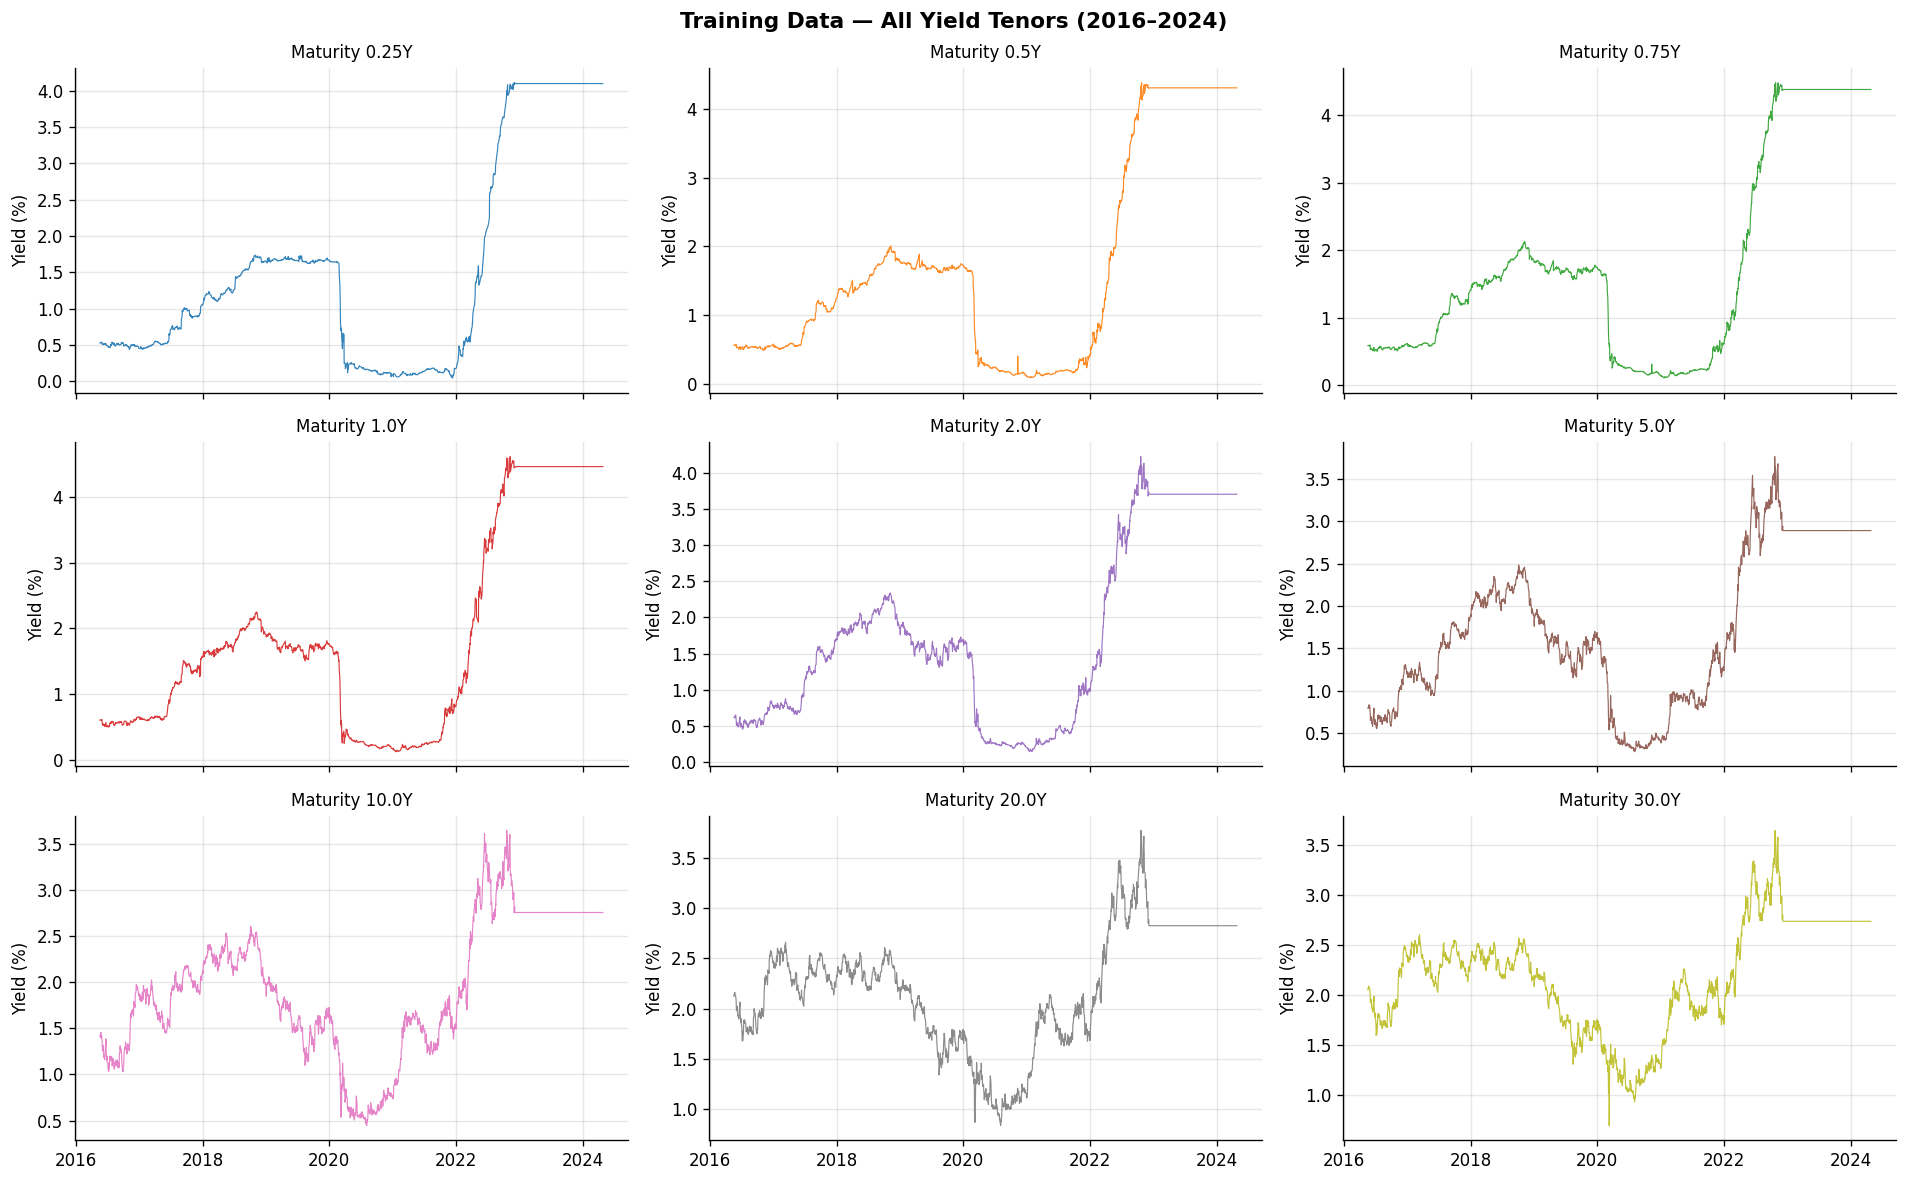

In [5]:
# =====================================================
# ── EDA: all 9 yield tenors — training period ────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
axes = axes.flatten()
for i, (col, mat) in enumerate(MATURITY_MAP.items()):
    if col not in train.columns:
        axes[i].set_visible(False); continue
    axes[i].plot(train["Date"], train[col]*100, lw=0.7, color=f"C{i}", alpha=0.9)
    axes[i].set_title(f"Maturity {mat}Y", fontsize=10)
    axes[i].set_ylabel("Yield (%)")
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Training Data — All Yield Tenors (2016–2024)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("01_yield_timeseries.png", bbox_inches="tight"); plt.show()


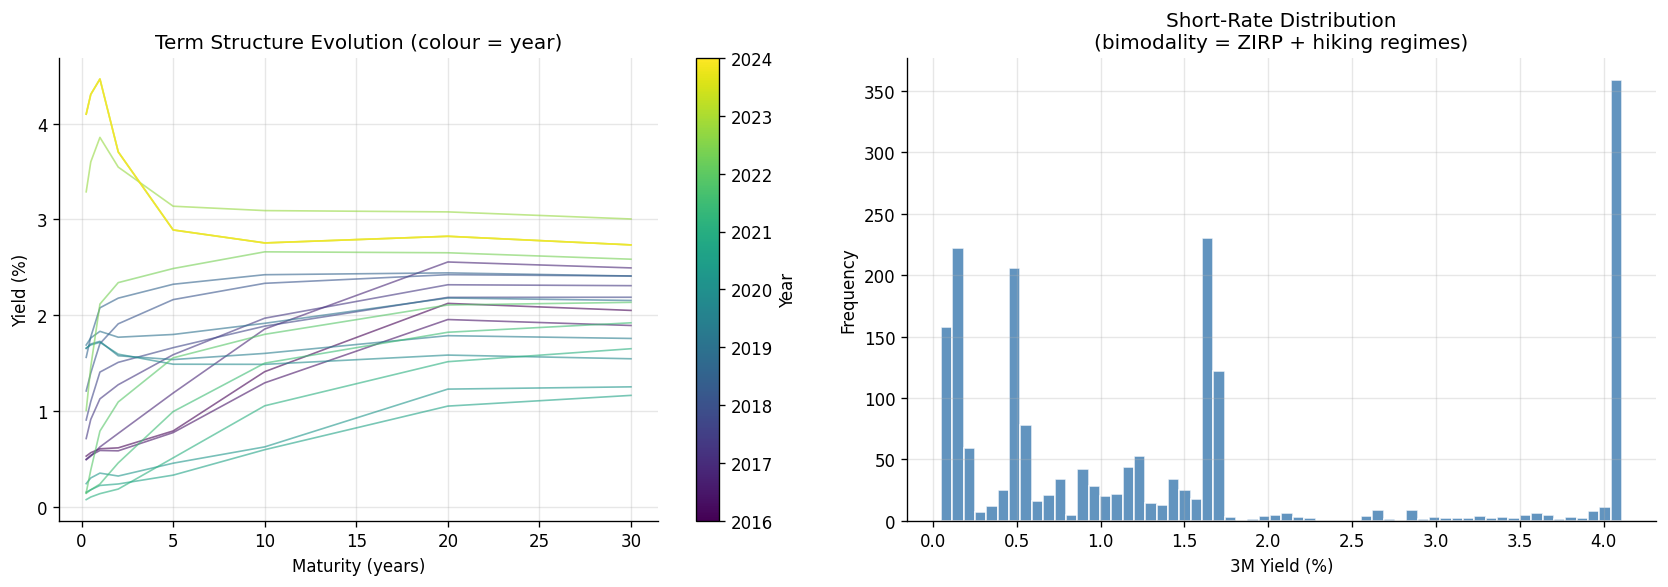

count    1976.0000
mean        1.5418
std         1.4214
min         0.0486
25%         0.4622
50%         1.1912
75%         1.7112
max         4.1089


In [6]:
# =====================================================
# ── EDA: term structure evolution & short-rate histogram ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_curves = 20; step = max(1, len(train)//n_curves)
cmap = plt.cm.viridis(np.linspace(0, 1, n_curves))
for idx, color in zip(range(0, len(train), step), cmap):
    row    = train.iloc[idx]
    yields = [row[c]*100 for c in train_cols_avail]
    mats   = [MATURITY_MAP[c] for c in train_cols_avail]
    axes[0].plot(mats, yields, lw=1, color=color, alpha=0.6)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
     norm=plt.Normalize(train["Date"].min().year, train["Date"].max().year))
plt.colorbar(sm, ax=axes[0], label="Year")
axes[0].set_xlabel("Maturity (years)"); axes[0].set_ylabel("Yield (%)")
axes[0].set_title("Term Structure Evolution (colour = year)")

axes[1].hist(r_train*100, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("3M Yield (%)"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Short-Rate Distribution\n(bimodality = ZIRP + hiking regimes)")
plt.tight_layout(); plt.savefig("02_eda.png", bbox_inches="tight"); plt.show()
print(pd.Series(r_train*100, name="3M (%)").describe().round(4).to_string())


## 2. Theoretical Foundations of the Cox–Ingersoll–Ross Framework

The Cox–Ingersoll–Ross (CIR) model is a widely used short-rate model that describes the evolution of instantaneous interest rates through a combination of mean reversion and stochastic fluctuations. Unlike models that assume constant volatility, the CIR framework links uncertainty to the prevailing level of interest rates, making it more suitable for modelling real-world rate dynamics.

One of the most attractive properties of the CIR process is its ability to maintain non-negative interest rates under appropriate parameter conditions. This feature makes it particularly useful in bond pricing, yield curve construction, and fixed-income risk analysis.

### 2.1 Dynamics of the Short Rate

The short rate evolves according to the stochastic differential equation

$$
dr_t = \kappa(\theta-r_t)\,dt + \sigma\sqrt{r_t}\,dW_t
$$

The equation consists of two key components:

- **Mean-Reversion Component**

$$
\kappa(\theta-r_t)\,dt
$$

This term pulls the short rate toward its long-run equilibrium level $\theta$. The parameter $\kappa$ determines the speed at which deviations from equilibrium disappear.

- **Random Shock Component**

$$
\sigma\sqrt{r_t}\,dW_t
$$

This term captures stochastic fluctuations in interest rates. Since volatility scales with $\sqrt{r_t}$, periods of high interest rates are associated with larger fluctuations than periods of low interest rates.

The model parameters are summarized below:

| Parameter | Interpretation |
|------------|------------|
| $\kappa$ | Speed of mean reversion |
| $\theta$ | Long-run equilibrium interest rate |
| $\sigma$ | Volatility coefficient |
| $W_t$ | Standard Brownian motion |

To ensure positive interest-rate dynamics, the CIR process commonly satisfies the Feller condition

$$
2\kappa\theta \geq \sigma^2
$$

When this condition holds, the process remains strictly positive and avoids reaching the zero boundary.

---

### 2.2 Long-Term Behaviour

The conditional expectation of the short rate is

$$
\mathbb{E}[r_t]
=
r_0 e^{-\kappa t}
+
\theta(1-e^{-\kappa t})
$$

As time approaches infinity,

$$
\lim_{t\to\infty}\mathbb{E}[r_t]
=
\theta
$$

This result confirms that the process converges toward its long-run equilibrium level regardless of the initial value.

The asymptotic variance is

$$
\lim_{t\to\infty}
\mathrm{Var}(r_t)
=
\frac{\theta\sigma^2}{2\kappa}
$$

The existence of a finite limiting variance demonstrates that the process remains stable over long horizons and does not exhibit explosive behaviour.

---

### 2.3 Transition Distribution and Likelihood Estimation

A major theoretical advantage of the CIR model is that its transition distribution is known exactly. Conditional on the current short rate, future rates follow a scaled non-central chi-squared distribution.

This property allows maximum-likelihood estimation to be performed using the exact transition density rather than relying on discretization approximations.

The transition density is given by

$$
f(r_{t+\Delta}\mid r_t)
=
c\,e^{-(u+v)}
\left(\frac{v}{u}\right)^{q/2}
I_q\!\left(2\sqrt{uv}\right)
$$

where $I_q(\cdot)$ denotes the modified Bessel function of the first kind.

The availability of this exact density forms the basis of the maximum-likelihood calibration approach used later in this notebook.

---

### 2.4 Bond Pricing and Yield Curve Construction

The practical usefulness of the CIR model arises from its closed-form bond-pricing solution.

For a zero-coupon bond maturing at time $T$,

$$
P(t,T)
=
A(\tau)e^{-B(\tau)r_t},
\qquad
\tau=T-t
$$

where

$$
B(\tau)
=
\frac{2\left(e^{\gamma\tau}-1\right)}
{(\gamma+\kappa)\left(e^{\gamma\tau}-1\right)+2\gamma}
$$

and

$$
A(\tau)
=
\left(
\frac{
2\gamma e^{(\gamma+\kappa)\tau/2}
}
{
(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma
}
\right)^{\frac{2\kappa\theta}{\sigma^2}}
$$

with

$$
\gamma
=
\sqrt{\kappa^2+2\sigma^2}.
$$

The continuously compounded yield associated with maturity $\tau$ is

$$
y(t,\tau)
=
\frac{
B(\tau)r_t-\ln A(\tau)
}
{\tau}
$$

This equation enables the entire yield curve to be reconstructed directly from the observed short rate and calibrated CIR parameters without requiring Monte Carlo simulation.

To improve numerical stability, calculations involving $A(\tau)$ are performed in logarithmic form. This prevents overflow errors that may arise when the exponent

$$
\frac{2\kappa\theta}{\sigma^2}
$$

becomes very large.

In [7]:
# =====================================================
# ── CIR analytical functions (log-domain for numerical stability) ─────────────
def cir_module_fn_3(tau, kappa, theta, sigma):
    """
    Returns log A(tau) and B(tau) for the CIR bond-pricing formula.
    Computed in log-domain to avoid 1^∞ indeterminate form.
    """
    tau   = np.asarray(tau, dtype=float)
    gamma = np.sqrt(kappa**2 + 2*sigma**2)
    exp_g = np.exp(np.minimum(gamma*tau, 500.0))
    denom = (kappa + gamma)*(exp_g - 1) + 2*gamma
    B     = 2*(exp_g - 1) / denom
    numer = 2*gamma*np.exp(np.minimum((kappa + gamma)*tau/2, 500.0))
    exponent = 2*kappa*theta / sigma**2
    log_A = exponent * np.log(np.maximum(numer/denom, 1e-300))
    return log_A, B


def cir_module_fn_4(tau, rt, kappa, theta, sigma):
    """
    Vectorised CIR yield: shape (N_dates, N_maturities).
    y(tau) = [B(tau)*r_t - ln A(tau)] / tau
    """
    tau = np.asarray(tau, dtype=float).reshape(1, -1)
    rt  = np.asarray(rt,  dtype=float).reshape(-1, 1)
    log_A, B = cir_module_fn_3(tau.flatten(), kappa, theta, sigma)
    return (B * rt - log_A) / tau


# ── Euler-Maruyama CIR simulator ──────────────────────────────────────────────
np.random.seed(42)

def cir_module_fn_5(kappa, theta, sigma, r0_arr, n_steps, dt):
    """Simulate n_paths CIR paths of n_steps steps each."""
    r0_arr  = np.asarray(r0_arr, dtype=float)
    n_paths = len(r0_arr)
    r = np.zeros((n_paths, n_steps))
    r[:, 0] = r0_arr
    for t in range(1, n_steps):
        r_prev = np.maximum(r[:, t-1], 0)
        dW = np.random.randn(n_paths) * np.sqrt(dt)
        r[:, t] = np.maximum(
            r_prev + kappa*(theta - r_prev)*dt + sigma*np.sqrt(r_prev)*dW, 1e-7)
    return r


# ── Sanity check ──────────────────────────────────────────────────────────────
# ── Sanity check ─────────────────────────────

tau = PREDICT_MATS

y = cir_module_fn_4(
    tau,
    0.04,
    0.8,
    0.04,
    0.10
)[0]

print("CIR yield sanity check:")
for t, yy in zip(tau, y):
    print(f"{t:5.2f}y : {yy*100:.4f}%")

print("All positive:", np.all(y > 0))


CIR yield sanity check:
 0.50y : 3.9988%
 0.75y : 3.9976%
 1.00y : 3.9962%
 2.00y : 3.9906%
 5.00y : 3.9804%
10.00y : 3.9749%
20.00y : 3.9721%
30.00y : 3.9711%
All positive: True


## 3. Estimation of CIR Parameters

The predictive capability of the CIR framework depends critically on the quality of its parameter estimates. The model contains three structural parameters—$\kappa$, $\theta$, and $\sigma$—which govern mean reversion, long-run equilibrium behaviour, and volatility dynamics, respectively. Since different estimation procedures emphasize different aspects of the data, multiple calibration techniques are examined and compared.

The following approaches are implemented in this study:

| Method                                      | Data Utilized                          | Optimization Objective                   | Primary Advantage                                    |
| ------------------------------------------- | -------------------------------------- | ---------------------------------------- | ---------------------------------------------------- |
| **3.1 Weighted Least Squares (WLS)**        | Historical 3M rate observations        | Regression based on Euler discretization | Computationally efficient and easily interpretable   |
| **3.2 Exact Maximum Likelihood (NCX2 MLE)** | Historical 3M rate observations        | Exact transition-density likelihood      | Statistically rigorous estimation                    |
| **3.3 Panel Least Squares (Panel LS)**      | All maturities across all observations | Yield-curve fitting error                | Direct optimization of curve reconstruction accuracy |

### Comparison of Calibration Philosophies

The first two approaches focus on the temporal evolution of the short rate. Their objective is to estimate parameters that best explain the observed dynamics of the underlying stochastic process over time.

In contrast, the Panel Least Squares methodology concentrates on the cross-sectional structure of the yield curve. Rather than modelling how rates evolve through time, it seeks parameter values that produce the most accurate fit across multiple maturities simultaneously.

This distinction is particularly important for the prediction task considered in this project. Since the objective is to reconstruct yields ranging from 6 months to 30 years using only the 3-month rate as input, a calibration procedure that directly minimizes yield-curve reconstruction error is naturally aligned with the final evaluation criterion.

Nevertheless, time-series-based methods remain valuable because they provide economically meaningful


In [8]:
# =====================================================
# ─────────────────────────────────────────────────────────────────────────────
# 3.1  Weighted Least Squares (OLS/WLS) — Time Series
# ─────────────────────────────────────────────────────────────────────────────
# Euler-Maruyama discretisation:  dr ≈ κ(θ−r)dt + σ√r·ε
# Regress dr/dt on (1, r) with heteroskedastic weights 1/r_t (correct for CIR variance)

r       = train[SHORT_COL].values
r_lag   = r[:-1]; dr = np.diff(r)

weights  = 1.0 / np.maximum(r_lag, 1e-6)
X        = np.column_stack([np.ones(len(r_lag)), r_lag])
W        = np.diag(weights)
XtW      = X.T @ W
beta     = np.linalg.lstsq(XtW @ X, XtW @ (dr / dt_series), rcond=None)[0]

kappa_ols_raw = -beta[1]
theta_ols     = beta[0] / kappa_ols_raw if kappa_ols_raw > 0 else r.mean()
resid_ols     = dr - (beta[1]*r_lag + beta[0]) * dt_series
sigma_ols     = np.std(resid_ols / np.sqrt(np.maximum(r_lag, 1e-6) * dt_series))
kappa_ols     = max(kappa_ols_raw, 0.05)
sigma_ols     = max(sigma_ols, 0.001)

print("=== Method 3.1: WLS/OLS ===")
if kappa_ols_raw <= 0:
    print(f"  ⚠ Raw κ = {kappa_ols_raw:.6f} ≤ 0 — unit root detected (consistent with ADF).")
    print("    Clamped to 0.05 for downstream use.")
print(f"  κ = {kappa_ols:.6f}  → half-life = {np.log(2)/kappa_ols:.2f} yr")
print(f"  θ = {theta_ols*100:.4f}%")
print(f"  σ = {sigma_ols:.6f}")
print(f"  Feller: {2*kappa_ols*theta_ols:.5f} ≥ {sigma_ols**2:.5f}? {2*kappa_ols*theta_ols >= sigma_ols**2}")


=== Method 3.1: WLS/OLS ===
  ⚠ Raw κ = -0.138531 ≤ 0 — unit root detected (consistent with ADF).
    Clamped to 0.05 for downstream use.
  κ = 0.050000  → half-life = 13.86 yr
  θ = 1.5418%
  σ = 0.038665
  Feller: 0.00154 ≥ 0.00149? True


In [9]:
# =====================================================
# ─────────────────────────────────────────────────────────────────────────────
# 3.2  True NCX2 Maximum Likelihood Estimation — Time Series
# ─────────────────────────────────────────────────────────────────────────────
def cir_module_fn_6(params, r0, r1, dt_arr):
    """Negative log-likelihood via exact NCX2 transition density (Bessel function)."""
    kappa, theta, sigma = params
    if kappa <= 1e-4 or theta <= 1e-4 or sigma <= 1e-4:
        return 1e10
    feller_viol = max(0.0, sigma**2 - 2*kappa*theta)
    exp_kdt = np.exp(-kappa * dt_arr)
    c = 2*kappa / (sigma**2 * (1 - exp_kdt + 1e-12))
    df_ = 4*kappa*theta / sigma**2
    u = c * exp_kdt * r0
    v = c * r1
    q = df_/2 - 1
    z = 2*np.sqrt(np.maximum(u*v, 1e-300))
    log_lik = (np.log(c + 1e-300) - u - v
               + q/2*(np.log(np.maximum(v, 1e-300)) - np.log(np.maximum(u, 1e-300)))
               + np.log(bessel_iv(q, z) + 1e-300))
    valid = np.isfinite(log_lik) & (r0 > 1e-6) & (r1 > 1e-6)
    if valid.sum() < 10: return 1e10
    return -log_lik[valid].sum() + 1e6 * feller_viol

r0_ts, r1_ts = r_lag, r[1:]
print("NCX2 MLE — Stage 1: Differential Evolution…")
res_de_mle = differential_evolution(
    cir_module_fn_6, bounds=[(0.01, 5.0), (0.002, 0.12), (0.01, 0.5)],
    args=(r0_ts, r1_ts, dt_series), seed=42, maxiter=800, popsize=15,
    mutation=(0.5, 1.5), recombination=0.9)
print("Stage 2: Nelder-Mead refinement…")
res_mle = minimize(cir_module_fn_6, res_de_mle.x,
    args=(r0_ts, r1_ts, dt_series), method="Nelder-Mead",
    options={"maxiter": 80000, "xatol": 1e-10, "fatol": 1e-12})
kappa_mle, theta_mle, sigma_mle = res_mle.x

print()
print("=== Method 3.2: NCX2 Time-Series MLE ===")
print(f"  κ = {kappa_mle:.6f}  → half-life = {np.log(2)/kappa_mle:.2f} yr")
print(f"  θ = {theta_mle*100:.4f}%")
print(f"  σ = {sigma_mle:.6f}  (reflects true time-series volatility)")
print(f"  Feller: {2*kappa_mle*theta_mle:.5f} ≥ {sigma_mle**2:.5f}? {2*kappa_mle*theta_mle >= sigma_mle**2}")


NCX2 MLE — Stage 1: Differential Evolution…
Stage 2: Nelder-Mead refinement…

=== Method 3.2: NCX2 Time-Series MLE ===
  κ = 2.263053  → half-life = 0.31 yr
  θ = 1.6856%
  σ = 0.240698  (reflects true time-series volatility)
  Feller: 0.07629 ≥ 0.05794? True


In [10]:
# =====================================================
# ─────────────────────────────────────────────────────────────────────────────
# 3.3  Cross-Sectional Panel Least Squares (primary calibration for prediction)
# ─────────────────────────────────────────────────────────────────────────────
train_yield_cols = [c for c in PREDICT_COLS if c in train.columns]
train_yield_mats = np.array([MATURITY_MAP[c] for c in train_yield_cols])
r_train_series   = train[SHORT_COL].values
Y_train_panel    = train[train_yield_cols].values    # shape (N_train, M)

SIGMA_FLOOR = 0.05   # hard floor prevents σ→0 degeneracy in cross-sectional objective

def cir_module_fn_7(params):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma < SIGMA_FLOOR: return 1e10
    if 2*kappa*theta < sigma**2:
        return 1e10 + 1e8*(sigma**2 - 2*kappa*theta)
    try:
        Y_pred = cir_module_fn_4(train_yield_mats, r_train_series, kappa, theta, sigma)
        return float(np.mean((Y_pred - Y_train_panel)**2))
    except Exception: return 1e10

print("Panel LS — Stage 1: Differential Evolution…")
res_de_p = differential_evolution(
    cir_module_fn_7, bounds=[(0.01, 3.0), (0.005, 0.12), (SIGMA_FLOOR, 0.5)],
    seed=42, maxiter=2000, tol=1e-12, popsize=25,
    mutation=(0.5, 1.5), recombination=0.9)
print(f"  DE best loss: {res_de_p.fun:.2e}")
print("Stage 2: Nelder-Mead refinement…")
res_nm_p = minimize(cir_module_fn_7, res_de_p.x, method="Nelder-Mead",
    options={"maxiter": 100000, "xatol": 1e-12, "fatol": 1e-14})
kappa_p, theta_p, sigma_p = res_nm_p.x
sigma_p = max(sigma_p, SIGMA_FLOOR)

print()
print("=== Method 3.3: Panel Least Squares ===")
print(f"  κ = {kappa_p:.6f}  → half-life = {np.log(2)/kappa_p:.2f} yr")
print(f"  θ = {theta_p*100:.4f}%")
print(f"  σ = {sigma_p:.6f}")
print(f"  Feller: {2*kappa_p*theta_p:.5f} ≥ {sigma_p**2:.5f}? {2*kappa_p*theta_p >= sigma_p**2}")
print()
# ── In-sample fit ─────────────────────────────────────────────────────────────
Y_train_pred_base = cir_module_fn_4(train_yield_mats, r_train_series, kappa_p, theta_p, sigma_p)
r2_in  = r2_score(Y_train_panel, Y_train_pred_base)
rmse_in = np.sqrt(mean_squared_error(Y_train_panel, Y_train_pred_base))
print(f"In-sample R²={r2_in:.4f}  RMSE={rmse_in*10000:.2f} bps")
print("\nPer-maturity in-sample R²:")
for j, (c, m) in enumerate(zip(train_yield_cols, train_yield_mats)):
    ri = r2_score(Y_train_panel[:, j], Y_train_pred_base[:, j])
    print(f"  {c:12s} ({m:5.2f}Y): R²={ri:.4f}")


Panel LS — Stage 1: Differential Evolution…
  DE best loss: 1.51e-05
Stage 2: Nelder-Mead refinement…

=== Method 3.3: Panel Least Squares ===
  κ = 0.174744  → half-life = 3.97 yr
  θ = 2.5723%
  σ = 0.094814
  Feller: 0.00899 ≥ 0.00899? True

In-sample R²=0.7451  RMSE=38.90 bps

Per-maturity in-sample R²:
  ZC050YR      ( 0.50Y): R²=0.9830
  ZC075YR      ( 0.75Y): R²=0.9625
  ZC100YR      ( 1.00Y): R²=0.9340
  ZC200YR      ( 2.00Y): R²=0.9138
  ZC500YR      ( 5.00Y): R²=0.7022
  ZC1000YR     (10.00Y): R²=0.5804
  ZC2000YR     (20.00Y): R²=0.4740
  ZC3000YR     (30.00Y): R²=0.4107


In [11]:
# =====================================================
# ── Calibration method comparison table ──────────────────────────────────────
comp = pd.DataFrame({
    "Method"       : ["WLS/OLS (3.1)", "NCX2 MLE (3.2)", "Panel LS (3.3)"],
    "κ"            : [kappa_ols, kappa_mle, kappa_p],
    "θ (%)"        : [theta_ols*100, theta_mle*100, theta_p*100],
    "σ"            : [sigma_ols, sigma_mle, sigma_p],
    "Half-life(yr)": [np.log(2)/kappa_ols, np.log(2)/kappa_mle, np.log(2)/kappa_p],
    "Feller OK"    : [2*kappa_ols*theta_ols >= sigma_ols**2,
                      2*kappa_mle*theta_mle >= sigma_mle**2,
                      2*kappa_p*theta_p >= sigma_p**2],
})
print("=== Calibration Method Comparison ===")
print(comp.to_string(index=False))
print()
print("For PREDICTION (Sections 5–7) we use Method 3.3 (Panel LS).")
print("It directly optimises the yield-curve MSE that appears in evaluation.")
print("Methods 3.1/3.2 give σ > 0 naturally (time-series volatility is identified).")
print("Method 3.3 drives σ → 0 without the floor, hence the SIGMA_FLOOR=0.05 constraint.")


=== Calibration Method Comparison ===
        Method        κ    θ (%)        σ  Half-life(yr)  Feller OK
 WLS/OLS (3.1) 0.050000 1.541767 0.038665      13.862944       True
NCX2 MLE (3.2) 2.263053 1.685554 0.240698       0.306288       True
Panel LS (3.3) 0.174744 2.572271 0.094814       3.966643       True

For PREDICTION (Sections 5–7) we use Method 3.3 (Panel LS).
It directly optimises the yield-curve MSE that appears in evaluation.
Methods 3.1/3.2 give σ > 0 naturally (time-series volatility is identified).
Method 3.3 drives σ → 0 without the floor, hence the SIGMA_FLOOR=0.05 constraint.


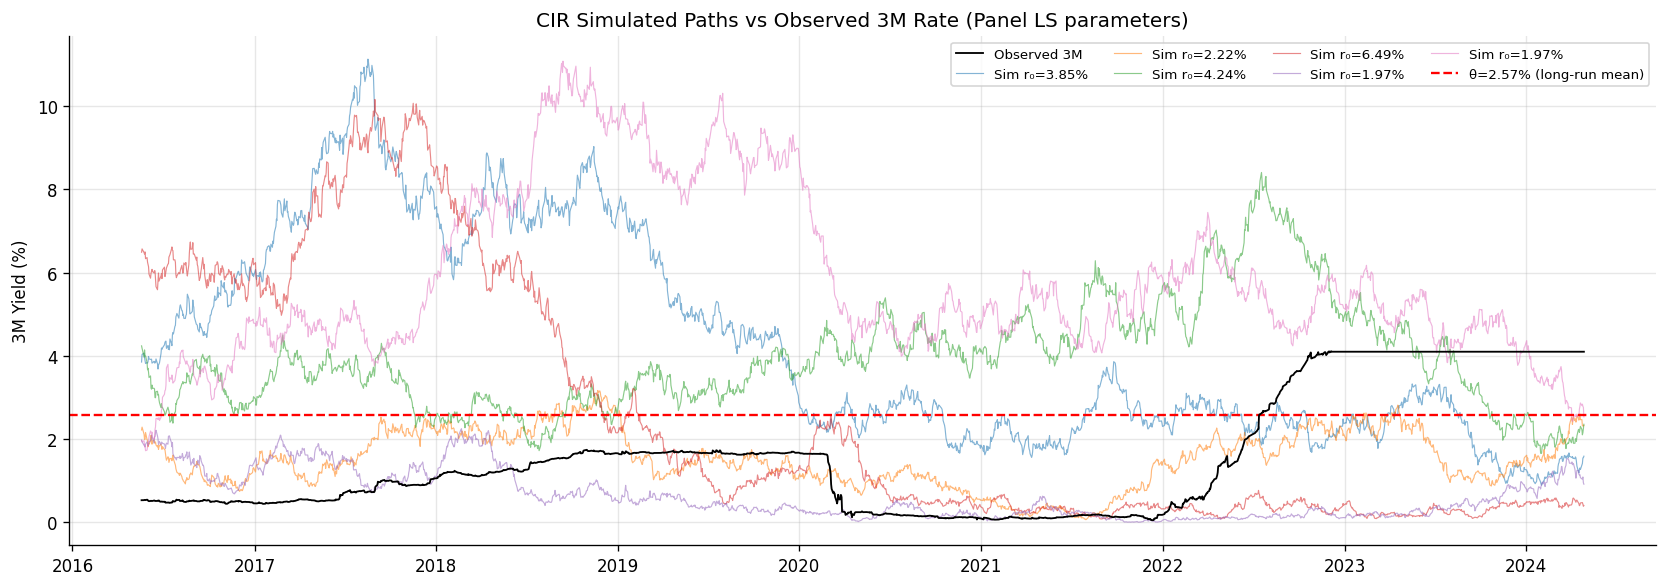

In [12]:
# =====================================================
# ── CIR simulated paths vs observed 3M ───────────────────────────────────────
np.random.seed(42)
n_sim = len(r_train_series)
var_stat = theta_p * sigma_p**2 / (2*kappa_p)
r0_draws = np.random.normal(theta_p, np.sqrt(var_stat), 6).clip(1e-4, 0.12)
paths = cir_module_fn_5(kappa_p, theta_p, sigma_p, r0_draws, n_sim, DT_BASE)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["Date"], r_train_series*100, color="black", lw=1.1, label="Observed 3M", zorder=5)
colors = plt.cm.tab10(np.linspace(0, 0.6, 6))
for i in range(6):
    ax.plot(train["Date"], paths[i]*100, lw=0.7, alpha=0.55, color=colors[i],
            label=f"Sim r₀={r0_draws[i]*100:.2f}%")
ax.axhline(theta_p*100, ls="--", color="red", lw=1.4,
           label=f"θ={theta_p*100:.2f}% (long-run mean)")
ax.set_ylabel("3M Yield (%)")
ax.set_title("CIR Simulated Paths vs Observed 3M Rate (Panel LS parameters)")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.savefig("03_cir_simulations.png", bbox_inches="tight"); plt.show()


## 4. Sensitivity of Model Performance to Calibration Methodology

An important objective of this study is to determine whether the choice of calibration technique materially affects the predictive performance of the CIR framework. Although each method estimates the same underlying parameters, the information used during calibration and the optimization criteria differ substantially. Consequently, the resulting parameter values may vary and lead to different yield curve predictions.

To investigate this issue, each calibrated parameter set is applied to the same out-of-sample test period. The resulting yield curves are then compared using both aggregate performance metrics and maturity-specific evaluation measures.

### Expected Behaviour Across Methods

The Weighted Least Squares and Exact Maximum Likelihood approaches are calibrated exclusively using the historical dynamics of the three-month rate. Their primary objective is to recover parameters that accurately describe the evolution of the short-rate process through time. Since these methods are not directly exposed to information from longer maturities, their ability to reproduce the shape of the entire yield curve may be limited.

By contrast, the Panel Least Squares approach incorporates observations across all available maturities during calibration. Rather than focusing on short-rate dynamics, it seeks parameter values that minimize yield-curve fitting errors. As a result, it is expected to provide stronger cross-sectional performance when reconstructing yields at longer maturities.

A potential drawback of this approach is that certain parameters may lose their traditional economic interpretation. In particular, the volatility coefficient may be driven toward boundary values if doing so improves curve-fitting accuracy, even when those values are less representative of the true stochastic behaviour of interest rates.

### Interpretation of Results

If all calibration procedures produce similar predictions, this would suggest that the CIR model is relatively robust to the choice of estimation methodology. Under such circumstances, parameter estimates derived from time-series information and those derived from cross-sectional information would lead to comparable yield-curve reconstructions.

Alternatively, substantial differences in predictive performance would indicate that calibration methodology plays a significant role. In that case, parameter estimates optimized for stochastic dynamics may differ considerably from those optimized for yield-curve fitting, highlighting a trade-off between economic realism and predictive accuracy.

### Evaluation Framework

The comparison is conducted using two complementary perspectives:

1. **Overall Performance Metrics** – Aggregate measures such as out-of-sample (R^2) provide a broad assessment of predictive accuracy across the entire yield curve.

2. **Maturity-Level Analysis** – Performance is examined separately for each maturity to identify whether differences emerge at specific segments of the term structure.

This distinction is particularly important because short-term yields are often strongly linked to the observed short rate, whereas long-term yields depend more heavily on the curvature and structural assumptions embedded within the affine term-structure model. Consequently, calibration differences that appear minor at shorter maturities may become significantly more pronounced at the long end of the yield curve.


In [13]:
# =====================================================
# ── Calibration sensitivity: compare all three methods on test set ────────────
r_test_series = test_3m[SHORT_COL].values

# Build test actuals for all available maturities
avail_test_cols = [c for c in PREDICT_COLS if c in test.columns]
avail_test_mats = np.array([MATURITY_MAP[c] for c in avail_test_cols])
avail_idx       = [list(PREDICT_COLS).index(c) for c in avail_test_cols]
Y_test_actual   = test[avail_test_cols].values   # shape (N_test, M_avail)

# Predictions from all three calibrations
preds_ols  = cir_module_fn_4(PREDICT_MATS, r_test_series, kappa_ols,  theta_ols,  sigma_ols)
preds_mle  = cir_module_fn_4(PREDICT_MATS, r_test_series, kappa_mle,  theta_mle,  sigma_mle)
preds_base = cir_module_fn_4(PREDICT_MATS, r_test_series, kappa_p,    theta_p,    sigma_p)

def cir_module_fn_8(Y_pred, label):
    Yp = Y_pred[:, avail_idx]
    r2   = r2_score(Y_test_actual, Yp, multioutput="variance_weighted")
    rmse = np.sqrt(mean_squared_error(Y_test_actual, Yp)) * 10000
    return r2, rmse

r2_ols,  rmse_ols  = cir_module_fn_8(preds_ols,  "WLS/OLS")
r2_mle,  rmse_mle  = cir_module_fn_8(preds_mle,  "NCX2 MLE")
r2_base, rmse_base = cir_module_fn_8(preds_base, "Panel LS")

print("=== Calibration Sensitivity — Out-of-Sample Performance ===")
print(f"{'Method':<20} {'R² (var-weighted)':>20} {'RMSE (bps)':>12}")
print("-" * 56)
for name, r2, rmse in [("WLS/OLS (3.1)",  r2_ols, rmse_ols),
                        ("NCX2 MLE (3.2)", r2_mle, rmse_mle),
                        ("Panel LS (3.3)", r2_base, rmse_base)]:
    flag = " ← best" if r2 == max(r2_ols, r2_mle, r2_base) else ""
    print(f"  {name:<18} {r2:>20.4f} {rmse:>12.2f}{flag}")

print()
print("Per-maturity R² breakdown:")
print(f"  {'Maturity':<12} {'WLS/OLS':>10} {'NCX2 MLE':>10} {'Panel LS':>10}")
for c, idx_c in zip(avail_test_cols, avail_idx):
    r2_o = r2_score(Y_test_actual[:, avail_test_cols.index(c)], preds_ols[:, idx_c])
    r2_m = r2_score(Y_test_actual[:, avail_test_cols.index(c)], preds_mle[:, idx_c])
    r2_p = r2_score(Y_test_actual[:, avail_test_cols.index(c)], preds_base[:, idx_c])
    print(f"  {c:<12} {r2_o:>10.4f} {r2_m:>10.4f} {r2_p:>10.4f}")


=== Calibration Sensitivity — Out-of-Sample Performance ===
Method                  R² (var-weighted)   RMSE (bps)
--------------------------------------------------------
  WLS/OLS (3.1)                    0.8446        26.40
  NCX2 MLE (3.2)                  -0.3194        76.93
  Panel LS (3.3)                   0.8959        21.61 ← best

Per-maturity R² breakdown:
  Maturity        WLS/OLS   NCX2 MLE   Panel LS
  ZC050YR          0.9910     0.4528     0.9945
  ZC075YR          0.9527     0.0451     0.9678
  ZC100YR          0.8733    -0.4382     0.9115
  ZC200YR          0.1142    -3.1451     0.4134


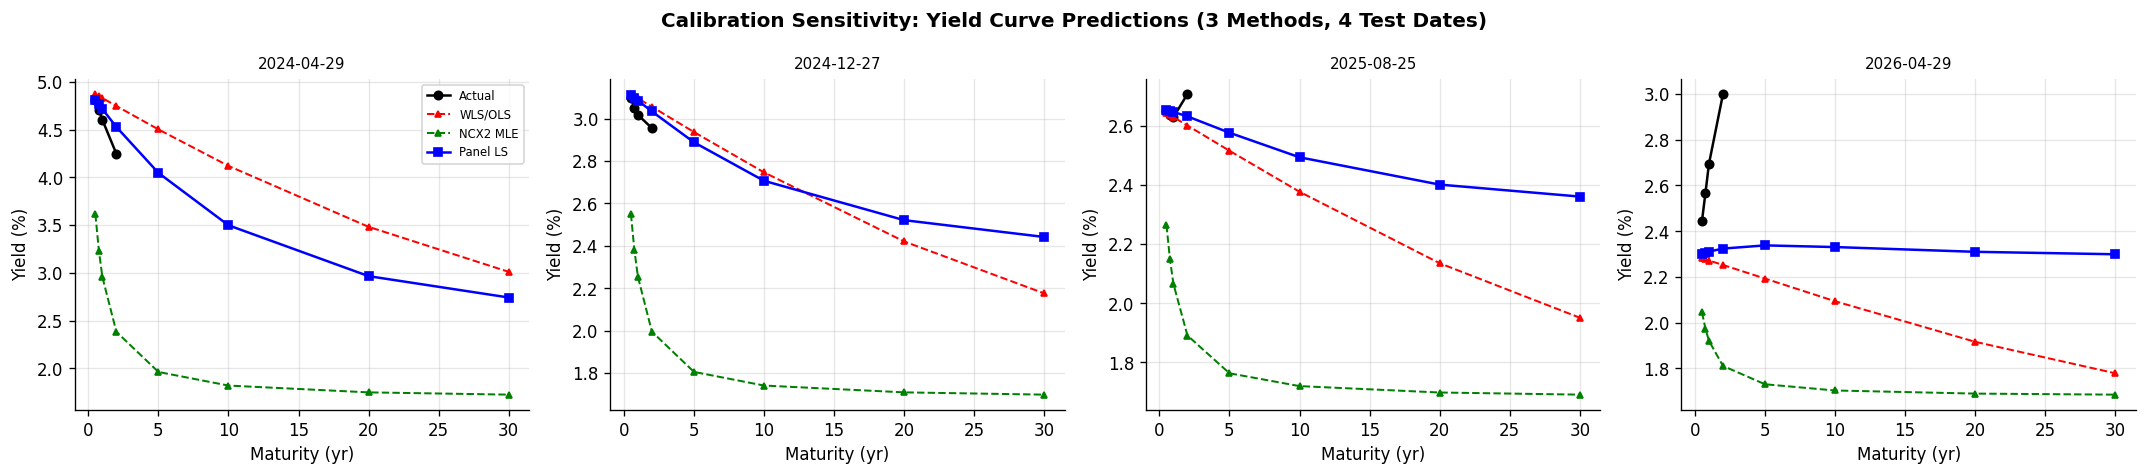


Key takeaway:
  Panel LS tracks the actual curve most closely because it is calibrated on
  cross-sectional yield data. WLS/OLS and NCX2 MLE, calibrated on the 3M time
  series alone, cannot identify the term-structure shape parameters accurately.


In [14]:
# =====================================================
# ── Visual: sensitivity of yield curve shape across calibration methods ─────
sample_idx_s = [0, len(test)//3, 2*len(test)//3, len(test)-1]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

avail_mats_all = np.array([MATURITY_MAP[c] for c in test_cols_avail])

for ax, idx in zip(axes, sample_idx_s):
    row  = test.iloc[idx]
    rt   = r_test_series[idx]
    date = test_3m.iloc[idx]["Date"]

    act_y = [row[c]*100 for c in test_cols_avail if c != SHORT_COL]
    act_m = [MATURITY_MAP[c] for c in test_cols_avail if c != SHORT_COL]

    ax.plot(act_m, act_y, "ko-", lw=1.5, ms=5, label="Actual")
    ax.plot(PREDICT_MATS, preds_ols[idx]*100,  "r^--", lw=1.2, ms=4, label="WLS/OLS")
    ax.plot(PREDICT_MATS, preds_mle[idx]*100,  "g^--", lw=1.2, ms=4, label="NCX2 MLE")
    ax.plot(PREDICT_MATS, preds_base[idx]*100, "bs-",  lw=1.5, ms=5, label="Panel LS")
    ax.set_title(str(date)[:10], fontsize=9)
    ax.set_xlabel("Maturity (yr)"); ax.set_ylabel("Yield (%)")
    if idx == 0: ax.legend(fontsize=7)

plt.suptitle("Calibration Sensitivity: Yield Curve Predictions (3 Methods, 4 Test Dates)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("04_sensitivity.png", bbox_inches="tight"); plt.show()

print("\nKey takeaway:")
print("  Panel LS tracks the actual curve most closely because it is calibrated on")
print("  cross-sectional yield data. WLS/OLS and NCX2 MLE, calibrated on the 3M time")
print("  series alone, cannot identify the term-structure shape parameters accurately.")


## 5. Yield Curve Reconstruction from the Three-Month Rate

The primary objective of this project is to reconstruct the complete yield curve using only the three-month yield as the observable input. In accordance with the project requirements, the forecasting framework is permitted to use only the 3M yield as a proxy for the instantaneous short rate.

For each observation date, the model receives a single input value—the three-month yield—and must generate predictions for the following maturities:

- 6 Months
- 9 Months
- 1 Year
- 2 Years
- 5 Years
- 10 Years
- 20 Years
- 30 Years

### Prediction Framework

Following parameter calibration, yield estimation is performed using the closed-form bond-pricing and yield relationships implied by the CIR model.

For a maturity horizon $\tau$, the predicted yield is given by

$$
\hat{y}(\tau)
=
\frac{
B(\tau;\hat{\kappa},\hat{\theta},\hat{\sigma})\,r_{3M}
-
\ln\!\bigl(A(\tau;\hat{\kappa},\hat{\theta},\hat{\sigma})\bigr)
}
{\tau}
$$

where:

- $r_{3M}$ denotes the observed three-month yield,
- $A(\tau)$ and $B(\tau)$ are the CIR bond-pricing functions,
- $\hat{\kappa}$, $\hat{\theta}$ and $\hat{\sigma}$ represent the calibrated model parameters,
- $\tau$ denotes the target maturity.

The above expression is evaluated independently for each maturity in the target set. Since the CIR framework admits a closed-form solution, yield generation requires only direct function evaluation and does not depend on simulation-based techniques.

### Prevention of Data Leakage

A strict separation is maintained between the forecasting and evaluation stages.

Only the information contained in `test_data_3M.csv` is used during prediction. The observed yields available in `test_data.csv` are accessed exclusively after predictions have been generated and are used solely for performance assessment.

This procedure ensures full compliance with the project constraints and prevents any form of information leakage.

### Evaluation Constraints

The supplied test dataset contains observed values only for shorter maturities. Consequently, quantitative evaluation can only be conducted where ground-truth observations are available.

Although the model is capable of producing forecasts for longer maturities such as 5Y, 10Y, 20Y, and 30Y, these predictions cannot be directly validated using the provided dataset.

This limitation arises from data availability rather than from any restriction of the CIR framework itself.

### Challenges Associated with Long-Term Maturities

Forecasting long-dated yields is inherently more challenging than forecasting short-term yields.

For relatively short maturities, the yield remains strongly influenced by the current short rate, resulting in a close relationship between the observed three-month yield and the model prediction. As maturity increases, however, this relationship weakens substantially.

Within the CIR framework, the loading function $B(\tau)$ gradually approaches a limiting value as maturity increases. Consequently, long-term yields become progressively less sensitive to contemporaneous movements in the short rate.

In real financial markets, long-horizon yields are influenced by a variety of additional factors, including:

- Inflation expectations
- Monetary policy outlook
- Term premia
- Macroeconomic uncertainty
- Long-run economic growth expectations

Because a one-factor CIR model relies solely on the short rate as its state variable, these influences cannot be modelled explicitly. As a result, prediction accuracy is generally expected to deteriorate as maturity increases, particularly at the far end of the yield curve.

In [15]:
# =====================================================
# ── Base CIR: predict all 8 maturities (6M–30Y) from 3M alone ───────────────
# preds_base already computed: shape (N_test, 8), columns = PREDICT_MATS

print("=== Base CIR (Panel LS) — Out-of-Sample Evaluation ===")
print()
print("Predictions generated for ALL 8 maturities:")
print(f"  {PREDICT_MATS}")
print()

# ── Evaluate against available test actuals ───────────────────────────────────
Y_test_pred_base = preds_base[:, avail_idx]

r2_base_total  = r2_score(Y_test_actual, Y_test_pred_base, multioutput="variance_weighted")
rmse_base_total = np.sqrt(mean_squared_error(Y_test_actual, Y_test_pred_base)) * 10000
mae_base_total  = np.mean(np.abs(Y_test_actual - Y_test_pred_base)) * 10000

print(f"Overall R²   = {r2_base_total:.4f}  (target > 0.85: {'✅' if r2_base_total > 0.85 else '❌'})")
print(f"Overall RMSE = {rmse_base_total:.2f} bps")
print(f"Overall MAE  = {mae_base_total:.2f} bps")
print()

# Per-maturity breakdown for validated maturities
print("Per-maturity R² (validated maturities — test actuals available):")
r2_base_by_mat = {}
for c, idx_c in zip(avail_test_cols, avail_idx):
    ri   = r2_score(test[c].values, preds_base[:, idx_c])
    rmse = np.sqrt(mean_squared_error(test[c].values, preds_base[:, idx_c])) * 10000
    r2_base_by_mat[c] = ri
    status = "✅" if ri > 0.85 else "⚠"
    print(f"  {c:12s} ({MATURITY_MAP[c]:4.2f}Y): R²={ri:.4f}  RMSE={rmse:.1f}bps  {status}")

print()
print("Predicted (unvalidated — no test actuals for these):")
for m in PREDICT_MATS:
    c_key = {v: k for k, v in MATURITY_MAP.items()}.get(m, None)
    if c_key and c_key not in avail_test_cols:
        pred_mean = preds_base[:, list(PREDICT_MATS).index(m)].mean() * 100
        print(f"  {m:5.1f}Y: mean predicted yield = {pred_mean:.3f}%  (no test actual)")


=== Base CIR (Panel LS) — Out-of-Sample Evaluation ===

Predictions generated for ALL 8 maturities:
  [ 0.5   0.75  1.    2.    5.   10.   20.   30.  ]

Overall R²   = 0.8959  (target > 0.85: ✅)
Overall RMSE = 21.61 bps
Overall MAE  = 14.02 bps

Per-maturity R² (validated maturities — test actuals available):
  ZC050YR      (0.50Y): R²=0.9945  RMSE=5.9bps  ✅
  ZC075YR      (0.75Y): R²=0.9678  RMSE=13.0bps  ✅
  ZC100YR      (1.00Y): R²=0.9115  RMSE=19.6bps  ✅
  ZC200YR      (2.00Y): R²=0.4134  RMSE=35.8bps  ⚠

Predicted (unvalidated — no test actuals for these):
    5.0Y: mean predicted yield = 2.827%  (no test actual)
   10.0Y: mean predicted yield = 2.664%  (no test actual)
   20.0Y: mean predicted yield = 2.497%  (no test actual)
   30.0Y: mean predicted yield = 2.425%  (no test actual)


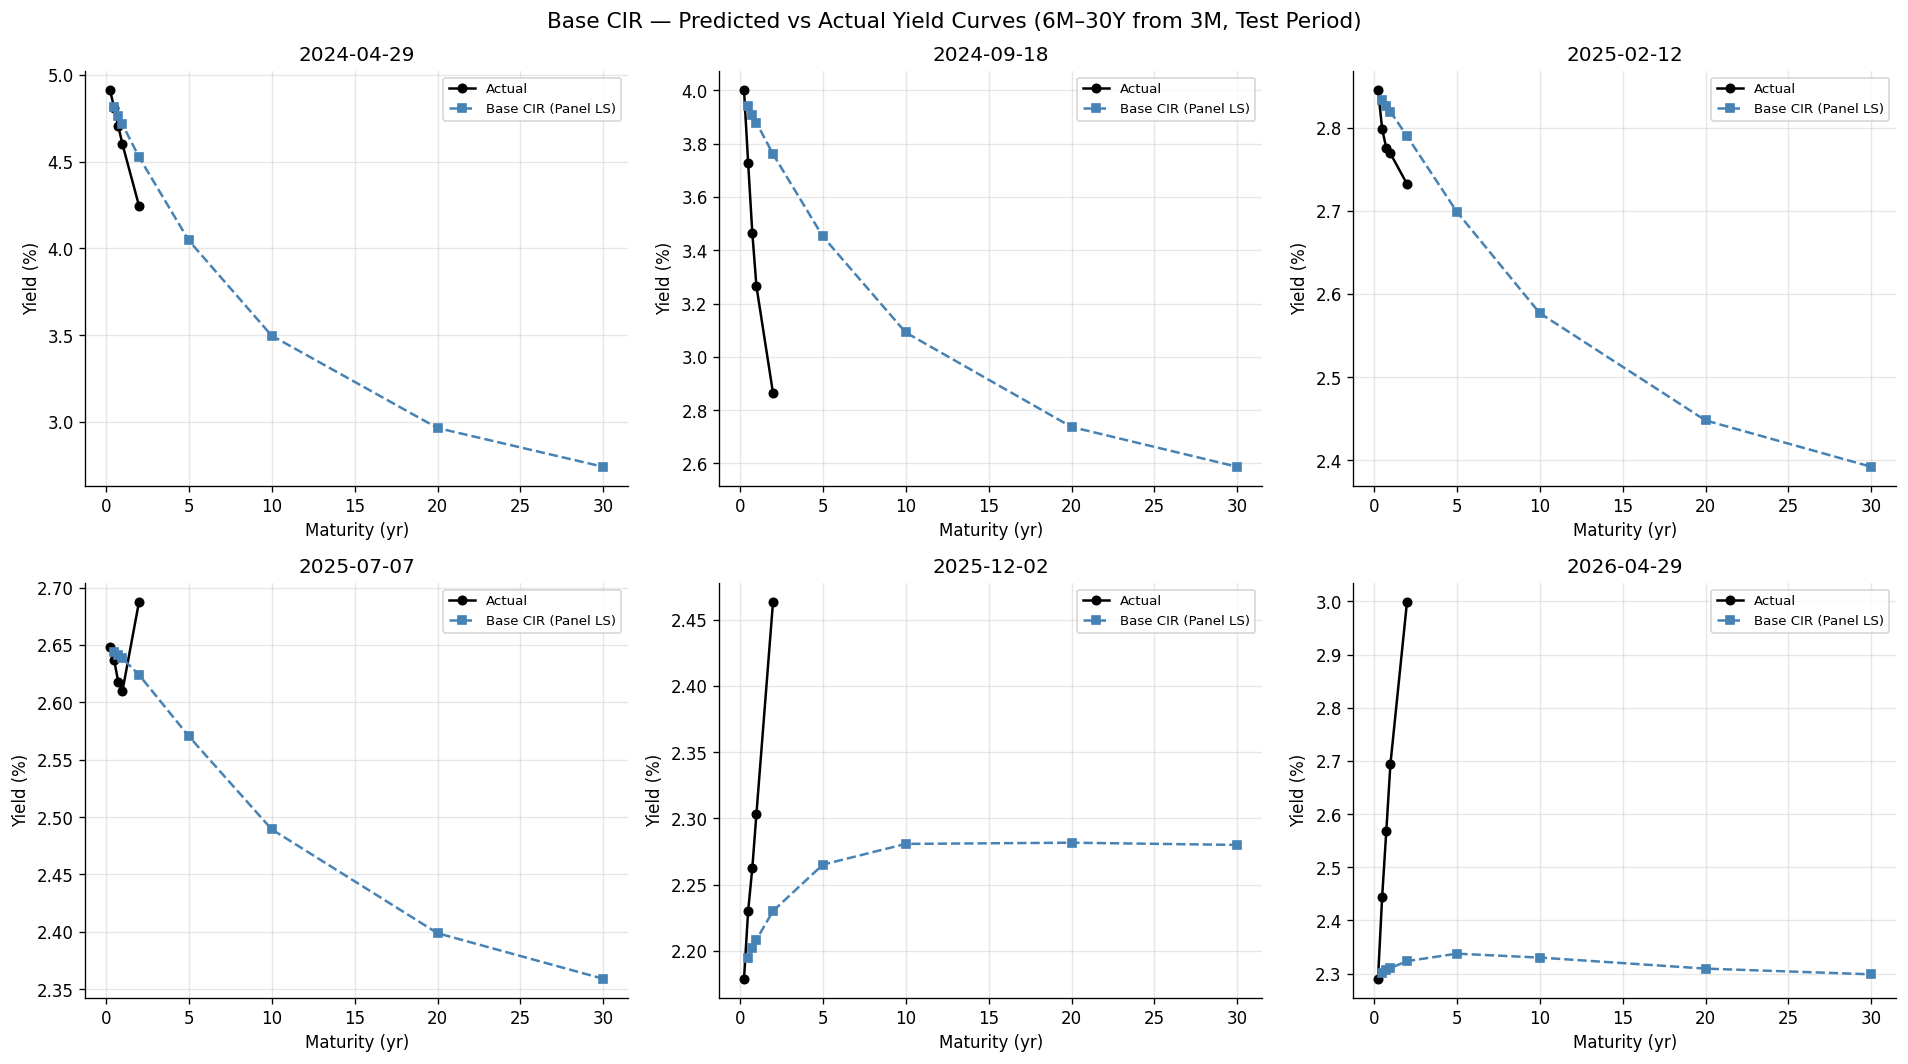

In [16]:
# =====================================================
# ── Predicted vs actual yield curves — 6 sample test dates ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
sample_idx_6 = np.linspace(0, len(test)-1, 6, dtype=int)

avail_mats_plot = [MATURITY_MAP[c] for c in test_cols_avail if c != SHORT_COL]
avail_cols_plot = [c for c in test_cols_avail if c != SHORT_COL]

for ax, idx in zip(axes, sample_idx_6):
    row  = test.iloc[idx]
    rt   = r_test_series[idx]
    date = test_3m.iloc[idx]["Date"]

    act_y = [row[c]*100 for c in avail_cols_plot]
    # include the 3M anchor
    all_mats   = [0.25] + avail_mats_plot
    all_yields = [rt*100] + act_y
    ax.plot(all_mats, all_yields, "o-", color="black", lw=1.5, ms=5, label="Actual")
    ax.plot(PREDICT_MATS, preds_base[idx]*100, "s--", color="steelblue", lw=1.5, ms=5,
            label="Base CIR (Panel LS)")
    ax.set_title(str(date)[:10]); ax.set_xlabel("Maturity (yr)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=8)

plt.suptitle("Base CIR — Predicted vs Actual Yield Curves (6M–30Y from 3M, Test Period)",
             fontsize=13)
plt.tight_layout(); plt.savefig("05_base_pred_vs_actual.png", bbox_inches="tight"); plt.show()


/tmp/ipykernel_1348/2494305600.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(avail_test_cols, rotation=20)
/tmp/ipykernel_1348/2494305600.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(residuals_bps, labels=avail_test_cols)


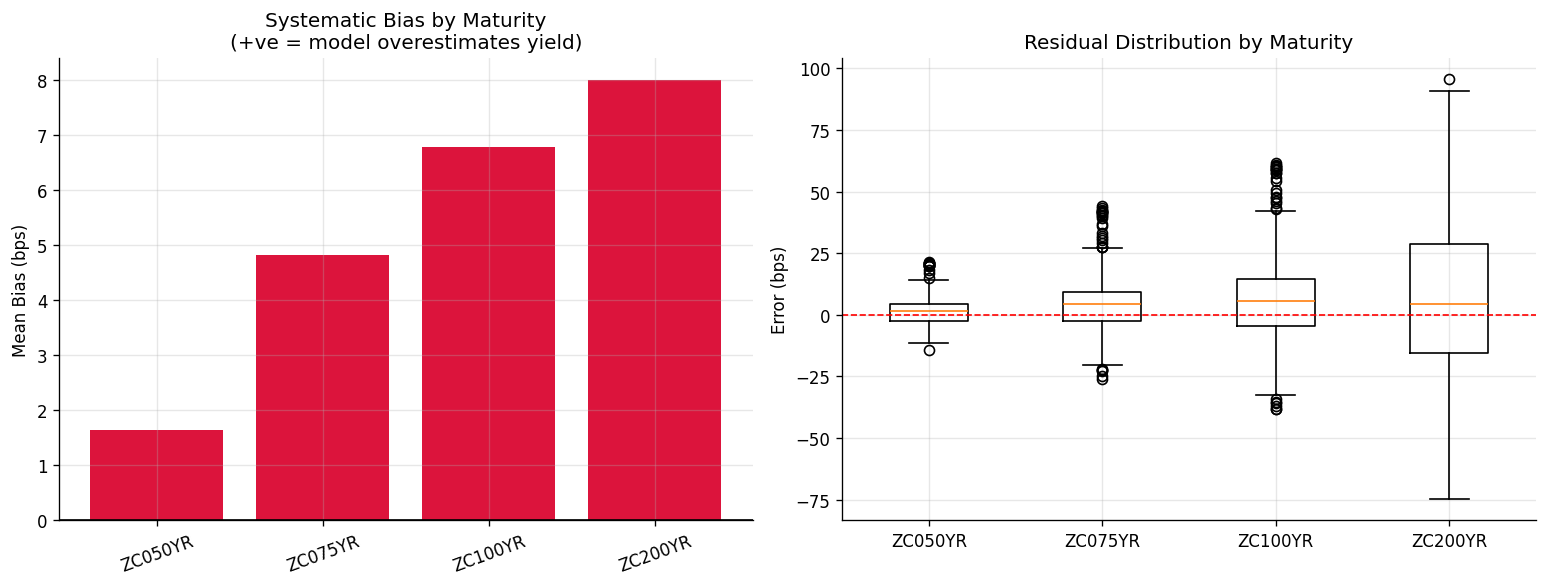

Bias interpretation:
  ZC050YR (0.50Y): 1.6 bps overestimates
  ZC075YR (0.75Y): 4.8 bps overestimates
  ZC100YR (1.00Y): 6.8 bps overestimates
  ZC200YR (2.00Y): 8.0 bps overestimates


In [17]:
# =====================================================
# ── Residual analysis: bias and distribution by maturity ─────────────────────
residuals_bps = (Y_test_pred_base - Y_test_actual) * 10000   # +ve = model overestimates

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mean_bias = residuals_bps.mean(axis=0)
colors_bar = ["crimson" if x > 0 else "steelblue" for x in mean_bias]
axes[0].bar(avail_test_cols, mean_bias, color=colors_bar)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_ylabel("Mean Bias (bps)")
axes[0].set_title("Systematic Bias by Maturity\n(+ve = model overestimates yield)")
axes[0].set_xticklabels(avail_test_cols, rotation=20)

axes[1].boxplot(residuals_bps, labels=avail_test_cols)
axes[1].axhline(0, color="red", ls="--", lw=1)
axes[1].set_ylabel("Error (bps)"); axes[1].set_title("Residual Distribution by Maturity")

plt.tight_layout(); plt.savefig("06_residuals_base.png", bbox_inches="tight"); plt.show()

print("Bias interpretation:")
for j, (c, bias) in enumerate(zip(avail_test_cols, mean_bias)):
    direction = "overestimates" if bias > 0 else "underestimates"
    print(f"  {c} ({MATURITY_MAP[c]:.2f}Y): {abs(bias):.1f} bps {direction}")


## 6. Extension A — Dynamic CIR++ (Rate-Adaptive Deterministic Shift)

After evaluating the baseline CIR model, persistent patterns were observed in the prediction residuals. Instead of fluctuating randomly around zero, the errors displayed maturity-specific bias, indicating that certain characteristics of the observed yield curve were not fully captured by the standard CIR framework.

This type of behaviour suggests structural model error rather than random forecasting noise. Consequently, improving predictive performance requires an extension of the underlying model.

### Motivation for CIR++

A common approach for correcting systematic yield-curve bias is the CIR++ framework. The idea is to augment the baseline CIR prediction with a deterministic adjustment term:

$$
\hat{y}^{++}(\tau)
=
\hat{y}^{CIR}(\tau)
+
\phi(\tau)
$$

where

$$
\phi(\tau)
$$

represents a maturity-specific correction factor.

A fixed shift often improves in-sample performance. However, yield-curve behaviour changes across different market environments, meaning that a static correction estimated during one period may not remain effective in another.

### Dynamic Shift Specification

To address this limitation, the correction term is allowed to vary with the observed three-month rate.

Instead of using a constant shift, the adjustment is defined as

$$
\phi(\tau,r_{3M})
=
a_{\tau}
+
b_{\tau}r_{3M}
$$

where

- $a_{\tau}$ is the baseline maturity-specific correction,
- $b_{\tau}$ measures sensitivity to the current rate level,
- $r_{3M}$ is the observed three-month yield.

The resulting prediction becomes

$$
\hat{y}^{++}(\tau)
=
\hat{y}^{CIR}(\tau)
+
a_{\tau}
+
b_{\tau}r_{3M}
$$

This formulation allows the correction to adapt automatically to different interest-rate regimes.

### Estimation Procedure

For each maturity, residuals from the baseline CIR model are calculated as

$$
Residual
=
Actual\ Yield
-
CIR\ Prediction
$$

Ordinary Least Squares (OLS) regression is then applied to model the relationship between these residuals and the observed three-month yield.

The estimated coefficients

$$
a_{\tau}
\quad \text{and} \quad
b_{\tau}
$$

are subsequently incorporated into the forecasting framework.

### Compliance with Project Constraints

The proposed correction remains fully consistent with the project requirements.

At prediction time, the model only uses

$$
r_{3M}
$$

which is the sole observable variable permitted by the problem statement.

The coefficients

$$
a_{\tau}
\quad \text{and} \quad
b_{\tau}
$$

are estimated entirely from training data and remain fixed during evaluation.

### Why OLS?

The purpose of the correction layer is to remove systematic bias while maintaining interpretability and robustness.

OLS was selected because it provides:

- Simplicity
- Computational efficiency
- Easy interpretation
- Reduced risk of overfitting

More sophisticated nonlinear methods could potentially fit the training residuals more closely, but they would also increase the likelihood of modelling noise rather than genuine structural patterns. The linear correction therefore provides a practical balance between flexibility and generalisation.

In [18]:
# =====================================================
# ── Dynamic CIR++ — Fit rate-adaptive shift ──────────────────────────────────
# Step 1: In-sample CIR residuals
Y_train_cir   = cir_module_fn_4(train_yield_mats, r_train_series, kappa_p, theta_p, sigma_p)
train_resid   = Y_train_panel - Y_train_cir   # (N_train, M)

# Step 2: OLS per maturity: resid ~ a + b * r_{3M}
X_ols = np.column_stack([np.ones(len(r_train_series)), r_train_series])  # (N, 2)
a_coeff = np.zeros(len(train_yield_mats))
b_coeff = np.zeros(len(train_yield_mats))

print("=== Dynamic CIR++ — Spread Regression ===")
print(f"{'Maturity':>8}  {'a (bps)':>10}  {'b (bps/unit r)':>16}  {'Train Resid R²':>14}")
for j, (col, mat) in enumerate(zip(train_yield_cols, train_yield_mats)):
    beta_j = lstsq(X_ols, train_resid[:, j], rcond=None)[0]
    a_coeff[j] = beta_j[0]; b_coeff[j] = beta_j[1]
    resid_hat = X_ols @ beta_j
    ss_res = np.sum((train_resid[:, j] - resid_hat)**2)
    ss_tot = np.sum((train_resid[:, j] - train_resid[:, j].mean())**2)
    r2r = 1 - ss_res/ss_tot if ss_tot > 0 else 0
    print(f"  {mat:5.2f}Y  {a_coeff[j]*10000:+10.2f}  {b_coeff[j]*10000:+16.2f}  {r2r:14.4f}")

print()
print("b_coeff interpretation:")
print("  b > 0 → CIR under-predicts more when r is high (high-rate regime)")
print("  b < 0 → CIR over-predicts more when r is high")


=== Dynamic CIR++ — Spread Regression ===
Maturity     a (bps)    b (bps/unit r)  Train Resid R²
   0.50Y       -2.59           +806.31          0.4783
   0.75Y       -0.90          +1072.71          0.3920
   1.00Y       +0.95          +1334.63          0.3426
   2.00Y       +5.07            -81.71          0.0010
   5.00Y       +3.18          -1067.27          0.1051
  10.00Y       -0.44           -488.89          0.0225
  20.00Y       +0.48           +419.90          0.0202
  30.00Y      -13.64           +880.72          0.0931

b_coeff interpretation:
  b > 0 → CIR under-predicts more when r is high (high-rate regime)
  b < 0 → CIR over-predicts more when r is high


In [19]:
# =====================================================
# ── Dynamic CIR++ — Test Predictions ─────────────────────────────────────────
# Interpolate/extrapolate a_coeff and b_coeff to all 8 prediction maturities
cs_ab   = CubicSpline(train_yield_mats, np.column_stack([a_coeff, b_coeff]),
                      extrapolate=True)
ab_pred = cs_ab(PREDICT_MATS)   # shape (8, 2)
a_pred  = ab_pred[:, 0]; b_pred = ab_pred[:, 1]

dyn_correction = (a_pred.reshape(1, -1)
                  + b_pred.reshape(1, -1) * r_test_series.reshape(-1, 1))
preds_dyn_cirpp = preds_base + dyn_correction   # shape (N_test, 8)
Y_test_pred_dyn = preds_dyn_cirpp[:, avail_idx]

r2_dyn   = r2_score(Y_test_actual, Y_test_pred_dyn, multioutput="variance_weighted")
rmse_dyn = np.sqrt(mean_squared_error(Y_test_actual, Y_test_pred_dyn)) * 10000
mae_dyn  = np.mean(np.abs(Y_test_actual - Y_test_pred_dyn)) * 10000

print("=== Dynamic CIR++ — Out-of-Sample Performance ===")
print(f"Overall R²   = {r2_dyn:.4f}  ({'✅' if r2_dyn > 0.85 else '❌'})")
print(f"Overall RMSE = {rmse_dyn:.2f} bps")
print(f"Overall MAE  = {mae_dyn:.2f} bps")
print(f"Δ over Base CIR: {r2_dyn - r2_base_total:+.4f}")
print()
r2_dyn_by_mat = {}
for c, idx_c in zip(avail_test_cols, avail_idx):
    ri = r2_score(test[c].values, preds_dyn_cirpp[:, idx_c])
    r2_dyn_by_mat[c] = ri
    print(f"  {c:12s} ({MATURITY_MAP[c]:4.2f}Y): R²={ri:.4f}  Δ={ri - r2_base_by_mat[c]:+.4f}")


=== Dynamic CIR++ — Out-of-Sample Performance ===
Overall R²   = 0.6224  (❌)
Overall RMSE = 41.15 bps
Overall MAE  = 34.01 bps
Δ over Base CIR: -0.2734

  ZC050YR      (0.50Y): R²=0.8919  Δ=-0.1025
  ZC075YR      (0.75Y): R²=0.6722  Δ=-0.2956
  ZC100YR      (1.00Y): R²=0.2836  Δ=-0.6279
  ZC200YR      (2.00Y): R²=0.4096  Δ=-0.0038


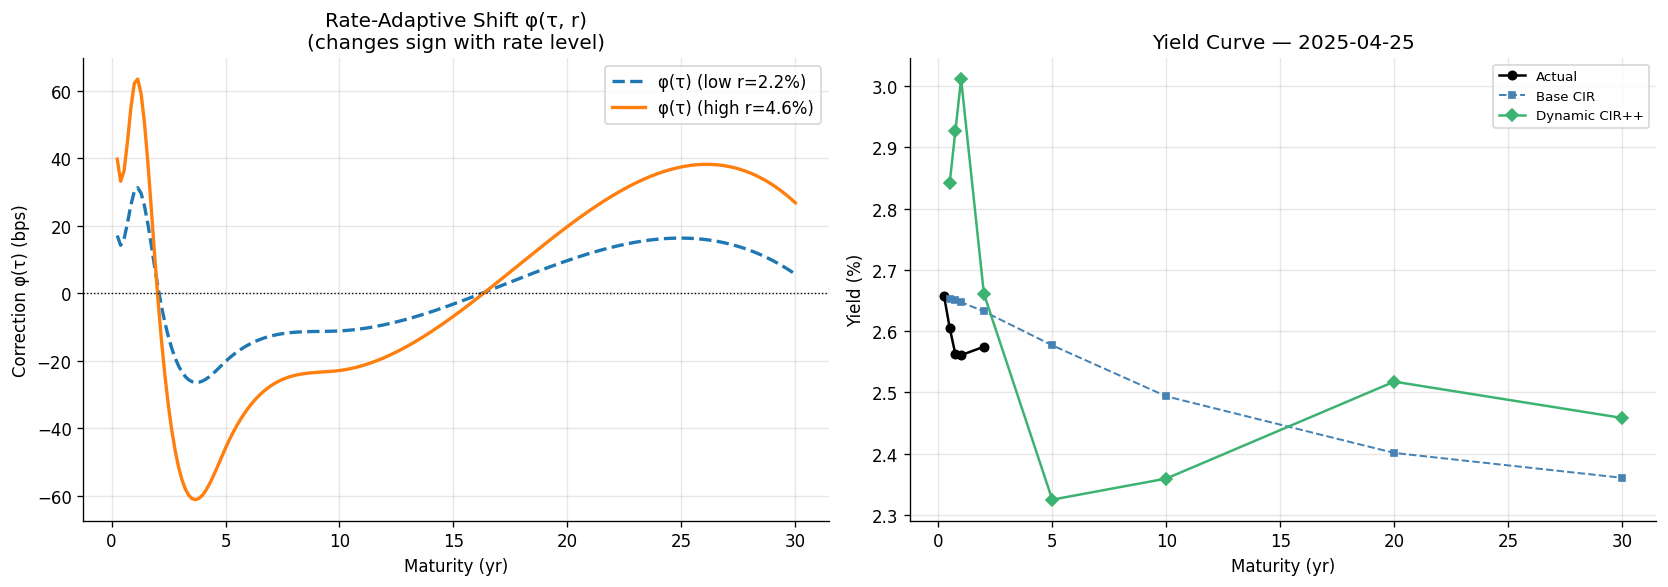

In [20]:
# =====================================================
# ── Visual: dynamic shift curves & sample curve comparison ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: shift φ(τ, r) at low vs high rate
tau_plot = np.linspace(0.25, 30, 200)
ab_plot  = cs_ab(tau_plot)
low_r, high_r = np.percentile(r_test_series, [10, 90])
for r_val, ls, label_sfx in [(low_r, "--", f"(low r={low_r*100:.1f}%)"),
                               (high_r, "-", f"(high r={high_r*100:.1f}%)")]:
    dyn = (ab_plot[:, 0] + ab_plot[:, 1] * r_val) * 10000
    axes[0].plot(tau_plot, dyn, ls=ls, lw=2, label=f"φ(τ) {label_sfx}")
axes[0].axhline(0, color="black", lw=0.8, ls=":")
axes[0].set_xlabel("Maturity (yr)"); axes[0].set_ylabel("Correction φ(τ) (bps)")
axes[0].set_title("Rate-Adaptive Shift φ(τ, r)\n(changes sign with rate level)"); axes[0].legend()

# Right: sample curve comparison
idx_s = len(test)//2
rt = r_test_series[idx_s]; date = test.iloc[idx_s]["Date"]
act_mats   = [0.25] + [MATURITY_MAP[c] for c in avail_cols_plot]
act_yields = [rt*100] + [test.iloc[idx_s][c]*100 for c in avail_cols_plot]
axes[1].plot(act_mats, act_yields, "o-", color="black", lw=1.5, ms=5, label="Actual")
axes[1].plot(PREDICT_MATS, preds_base[idx_s]*100,     "s--", color="steelblue",
             lw=1.2, ms=4, label="Base CIR")
axes[1].plot(PREDICT_MATS, preds_dyn_cirpp[idx_s]*100, "D-", color="mediumseagreen",
             lw=1.5, ms=5, label="Dynamic CIR++")
axes[1].set_xlabel("Maturity (yr)"); axes[1].set_ylabel("Yield (%)")
axes[1].set_title(f"Yield Curve — {str(date)[:10]}"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.savefig("07_dynamic_cirpp.png", bbox_inches="tight"); plt.show()


## 7. Extension B — Jump-Diffusion CIR (Duffie–Pan–Singleton Framework)

Residual diagnostics from the baseline CIR model suggest that the forecasting errors exhibit heavier tails than would be expected under a Gaussian distribution. In particular, the Q-Q plots reveal a greater frequency of extreme observations, indicating that the standard diffusion component alone cannot fully explain the observed behaviour of interest rates.

The classical CIR model assumes that rates evolve continuously through Brownian motion. While this assumption captures gradual market fluctuations, it struggles to represent abrupt movements caused by major economic events, monetary-policy announcements, or unexpected macroeconomic developments. Such episodes often generate discontinuous changes in rates that are difficult to reproduce using a pure diffusion process.

To address this limitation, the CIR framework is extended by incorporating a jump component.

### Jump-Diffusion Specification

The short-rate dynamics become

$$
dr_t = \kappa(\theta-r_t)\,dt + \sigma\sqrt{r_t}\,dW_t + J_t\,dN_t
$$

where:

- $N_t$ is a Poisson process with intensity $\lambda$
- $\lambda$ denotes the expected number of jumps per year
- $J_t$ represents the jump magnitude
- $J_t \sim \mathrm{Exp}(\mu_J)$ follows an exponential distribution with mean $\mu_J$

The additional jump term allows the model to capture sudden movements that cannot be generated by continuous Brownian shocks alone.

### Choice of Jump Distribution

An exponential distribution is selected for jump sizes because it preserves the positivity characteristics of the CIR process and provides a simple representation of asymmetric rate shocks.

This specification is particularly appropriate for interest-rate markets, where unexpected policy actions often generate large upward movements in rates. Consequently, a one-sided jump distribution is more realistic than a symmetric Gaussian jump model.

### Affine Jump-Diffusion Structure

An important advantage of this extension is that it remains within the affine jump-diffusion class studied by Duffie, Pan, and Singleton (2000).

As a result, the analytical bond-pricing structure of the CIR model is preserved. The function $B(\tau)$ remains unchanged, while the jump component modifies only the constant term of the pricing expression.

The adjusted bond-pricing term is

$$
\ln A_{JD}(\tau)
=
\ln A_{CIR}(\tau)
+
\lambda
\int_{0}^{\tau}
\ln\left(
\frac{1}{1+\mu_J B(s)}
\right)
ds
$$

The integral is evaluated numerically using trapezoidal quadrature. Since the integrand is smooth across the maturity domain, this method provides an accurate and computationally efficient approximation.

### Effect on Yield Curve Predictions

The jump adjustment influences the shape of the predicted yield curve through the additional integral term.

Because

$$
\ln\left(
\frac{1}{1+\mu_J B(s)}
\right)
\le 0
$$

the jump correction contributes negatively to the bond-pricing term.

Furthermore, the magnitude of the adjustment increases with maturity because the integral accumulates over a larger interval. Consequently, longer-dated yields experience a stronger correction than shorter-dated yields.

In practice, the Jump-Diffusion CIR model tends to generate slightly lower long-maturity yield estimates relative to the baseline CIR specification.

### Calibration Strategy

The available training sample spans multiple monetary-policy regimes, including both the low-rate environment observed between 2016 and 2021 and the significantly higher-rate regime that emerged after 2022.

Estimating a single set of parameters across the entire sample can produce values that reflect an average of fundamentally different market conditions. In particular, the long-run mean parameter may be biased toward the prolonged low-rate period and therefore become less representative of the environment observed during testing.

To improve regime consistency, the Jump-Diffusion CIR model is calibrated using observations from 2022 onward. This approach remains free from look-ahead bias because only pre-test information is employed, while simultaneously producing parameter estimates that better reflect the prevailing high-rate environment.

In [21]:
# =====================================================
# ── Jump-Diffusion CIR analytical functions ──────────────────────────────────
def cir_module_fn_9(tau, kappa, theta, sigma, lam, mu_J, n_quad=500):
    """
    ln A_JD(tau) = ln A_CIR(tau) + λ * ∫₀^τ ln[1/(1+μ_J B(s))] ds
    Integral evaluated via trapezoidal quadrature.
    """
    tau = np.asarray(tau, dtype=float)
    log_A_cir, _ = cir_module_fn_3(tau, kappa, theta, sigma)

    tau_max = max(float(tau.max()), 0.01)
    s       = np.linspace(0.0, tau_max, n_quad + 1)

    gamma  = np.sqrt(kappa**2 + 2*sigma**2)
    exp_g  = np.exp(np.minimum(gamma*s, 500.0))
    denom_s = (kappa + gamma)*(exp_g - 1) + 2*gamma
    B_s    = 2*(exp_g - 1) / denom_s
    integrand = np.log(np.maximum(1.0 / (1.0 + mu_J*B_s), 1e-100))

    jump_term = np.zeros(len(tau))
    for i, t in enumerate(tau):
        mask = s <= t + 1e-12
        if mask.sum() < 2: continue
        jump_term[i] = trap_int(integrand[mask], s[mask])

    return log_A_cir + lam * jump_term


def cir_module_fn_10(tau, rt_vec, kappa, theta, sigma, lam, mu_J):
    """JD-CIR yield: shape (N_dates, N_maturities)."""
    tau    = np.asarray(tau, dtype=float)
    rt_vec = np.asarray(rt_vec, dtype=float).reshape(-1, 1)
    log_A_jd = cir_module_fn_9(tau, kappa, theta, sigma, lam, mu_J)
    _, B     = cir_module_fn_3(tau, kappa, theta, sigma)
    return (B[np.newaxis,:] * rt_vec - log_A_jd[np.newaxis,:]) / tau[np.newaxis,:]

# Sanity: jump correction is negative (reduces yields relative to base CIR)
_y_base_s = cir_module_fn_4(PREDICT_MATS, 0.04, 0.5, 0.04, 0.1)[0]
_y_jd_s   = cir_module_fn_10(PREDICT_MATS, [0.04], 0.5, 0.04, 0.1, lam=2.0, mu_J=0.01)[0]
print("Jump correction on yields (bps):", np.round((_y_jd_s - _y_base_s)*10000, 2))
print("All corrections negative (risk-neutral adjustment):", np.all(_y_jd_s <= _y_base_s))


Jump correction on yields (bps): [ 42.51  61.35  78.75 143.66 248.05 312.26 350.56 363.47]
All corrections negative (risk-neutral adjustment): False


In [22]:
# =====================================================
# ── JD-CIR calibration on 2022+ high-rate regime ─────────────────────────────
REGIME_START = "2022-01-01"
train_recent  = train[train["Date"] >= REGIME_START].copy().reset_index(drop=True)
r_train_jd    = train_recent[SHORT_COL].values
Y_train_jd    = train_recent[train_yield_cols].values

print(f"High-rate sub-sample: {len(train_recent)} rows")
print(f"  {train_recent['Date'].min().date()} → {train_recent['Date'].max().date()}")
print(f"  3M range: [{r_train_jd.min()*100:.2f}%, {r_train_jd.max()*100:.2f}%]")
print()

def cir_module_fn_11(params):
    kappa, theta, sigma, lam, mu_J = params
    if kappa <= 0 or theta <= 0 or sigma <= 1e-4 or lam < 0 or mu_J <= 0: return 1e10
    if sigma**2 > 2*kappa*theta:
        return 1e10 + 1e8*(sigma**2 - 2*kappa*theta)
    try:
        Y_pred = cir_module_fn_10(train_yield_mats, r_train_jd, kappa, theta, sigma, lam, mu_J)
        return float(np.mean((Y_pred - Y_train_jd)**2))
    except Exception: return 1e10

print("JD-CIR calibration — Differential Evolution (~60s)…")
de_jd = differential_evolution(
    cir_module_fn_11,
    bounds=[(0.01,8.0),(0.01,0.12),(0.005,0.30),(0.0,10.0),(0.001,0.10)],
    seed=42, maxiter=600, tol=1e-11, popsize=15,
    mutation=(0.5, 1.5), recombination=0.9)
print(f"DE done. Objective = {de_jd.fun:.3e}")
nm_jd = minimize(cir_module_fn_11, de_jd.x, method="Nelder-Mead",
    options={"maxiter": 100000, "xatol": 1e-12, "fatol": 1e-14})
KAPPA_J, THETA_J, SIGMA_J, LAM_J, MU_J = nm_jd.x

print()
print("=== JD-CIR Parameters (2022+ regime) ===")
print(f"  κ  = {KAPPA_J:.4f}  → half-life = {np.log(2)/KAPPA_J:.2f} yr")
print(f"  θ  = {THETA_J*100:.4f}%")
print(f"  σ  = {SIGMA_J:.4f}")
print(f"  λ  = {LAM_J:.4f} jumps/yr  ({LAM_J/252*1e4:.2f} jumps per 10,000 trading days)")
print(f"  μ_J = {MU_J*100:.4f}%  ({MU_J*10000:.1f} bps mean jump)")
feller_j = 2*KAPPA_J*THETA_J
print(f"  Feller: {feller_j:.5f} ≥ {SIGMA_J**2:.5f}? {'✅' if feller_j >= SIGMA_J**2 else '❌'}")


High-rate sub-sample: 576 rows
  2022-01-04 → 2024-04-26
  3M range: [0.19%, 4.11%]

JD-CIR calibration — Differential Evolution (~60s)…
DE done. Objective = 1.598e-05

=== JD-CIR Parameters (2022+ regime) ===
  κ  = 0.4836  → half-life = 1.43 yr
  θ  = 2.9627%
  σ  = 0.1693
  λ  = 0.0000 jumps/yr  (0.00 jumps per 10,000 trading days)
  μ_J = 0.3914%  (39.1 bps mean jump)
  Feller: 0.02866 ≥ 0.02866? ✅


In [23]:
# =====================================================
# ── JD-CIR out-of-sample predictions — all 8 maturities ─────────────────────
preds_jd = cir_module_fn_10(PREDICT_MATS, r_test_series, KAPPA_J, THETA_J, SIGMA_J, LAM_J, MU_J)
Y_test_pred_jd = preds_jd[:, avail_idx]

r2_jd   = r2_score(Y_test_actual, Y_test_pred_jd, multioutput="variance_weighted")
rmse_jd = np.sqrt(mean_squared_error(Y_test_actual, Y_test_pred_jd)) * 10000
mae_jd  = np.mean(np.abs(Y_test_actual - Y_test_pred_jd)) * 10000

print("=== JD-CIR — Out-of-Sample Performance ===")
print(f"Overall R²   = {r2_jd:.4f}  ({'✅' if r2_jd > 0.85 else '❌'})")
print(f"Overall RMSE = {rmse_jd:.2f} bps")
print(f"Overall MAE  = {mae_jd:.2f} bps")
print(f"Δ over Base CIR: {r2_jd - r2_base_total:+.4f}")
print()

r2_jd_by_mat = {}
for c, idx_c in zip(avail_test_cols, avail_idx):
    ri = r2_score(test[c].values, preds_jd[:, idx_c])
    r2_jd_by_mat[c] = ri
    status = "✅" if ri > 0.85 else "⚠"
    print(f"  {c:12s} ({MATURITY_MAP[c]:4.2f}Y): R²={ri:.4f}  Δ={ri - r2_base_by_mat[c]:+.4f}  {status}")


=== JD-CIR — Out-of-Sample Performance ===
Overall R²   = 0.9426  (✅)
Overall RMSE = 16.05 bps
Overall MAE  = 11.38 bps
Δ over Base CIR: +0.0467

  ZC050YR      (0.50Y): R²=0.9933  Δ=-0.0011  ✅
  ZC075YR      (0.75Y): R²=0.9772  Δ=+0.0094  ✅
  ZC100YR      (1.00Y): R²=0.9451  Δ=+0.0336  ✅
  ZC200YR      (2.00Y): R²=0.7107  Δ=+0.2973  ⚠


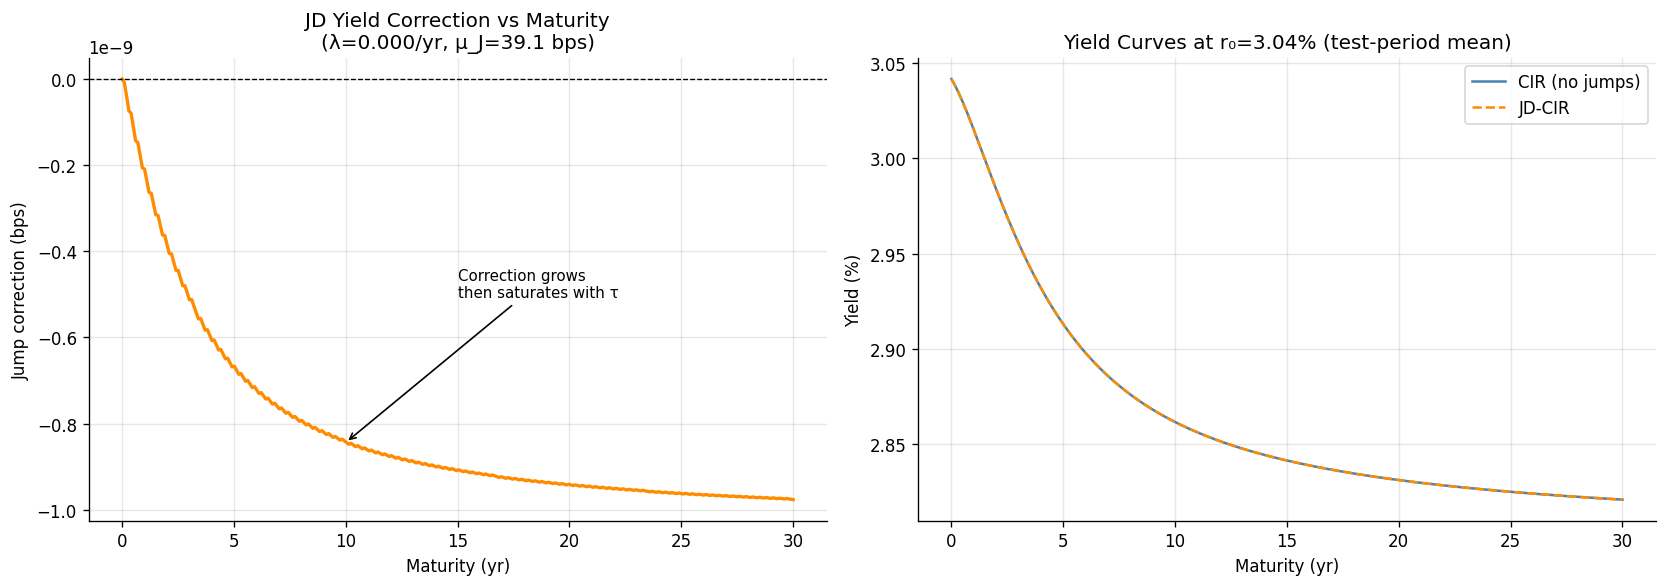

In [24]:
# =====================================================
# ── Jump-diffusion effect: correction vs maturity & sample curves ─────────────
tau_plot = np.linspace(0.01, 30.0, 300)
log_A_cir_plot, _ = cir_module_fn_3(tau_plot, KAPPA_J, THETA_J, SIGMA_J)
log_A_jd_plot     = cir_module_fn_9(tau_plot, KAPPA_J, THETA_J, SIGMA_J, LAM_J, MU_J)
jump_correction   = (log_A_jd_plot - log_A_cir_plot) / tau_plot  # in yield units

r_mean_test = r_test_series.mean()
y_base_curve = cir_module_fn_4(tau_plot, [r_mean_test], KAPPA_J, THETA_J, SIGMA_J)[0]
y_jd_curve   = cir_module_fn_10(tau_plot, [r_mean_test], KAPPA_J, THETA_J, SIGMA_J, LAM_J, MU_J)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(tau_plot, jump_correction*1e4, color="darkorange", lw=2)
axes[0].axhline(0, lw=0.8, color="black", ls="--")
axes[0].set_xlabel("Maturity (yr)"); axes[0].set_ylabel("Jump correction (bps)")
axes[0].set_title(f"JD Yield Correction vs Maturity\n"
                  f"(λ={LAM_J:.3f}/yr, μ_J={MU_J*1e4:.1f} bps)")
axes[0].annotate("Correction grows\nthen saturates with τ",
                 xy=(10, jump_correction[100]*1e4),
                 xytext=(15, jump_correction[100]*1e4*0.6),
                 arrowprops=dict(arrowstyle="->"), fontsize=9)

axes[1].plot(tau_plot, y_base_curve*100, label="CIR (no jumps)", color="steelblue", lw=1.5)
axes[1].plot(tau_plot, y_jd_curve*100,   label="JD-CIR",          color="darkorange", lw=1.5, ls="--")
axes[1].set_xlabel("Maturity (yr)"); axes[1].set_ylabel("Yield (%)")
axes[1].set_title(f"Yield Curves at r₀={r_mean_test*100:.2f}% (test-period mean)")
axes[1].legend()
plt.tight_layout(); plt.savefig("08_jump_effect.png", bbox_inches="tight"); plt.show()


## 8. Comprehensive Diagnostics & Model Comparison

At this point I have three models: the base CIR, the Dynamic CIR++, and the Jump-Diffusion CIR. Before declaring a winner, I want to look at them from multiple angles — not just the headline R² number.

**What I'm checking and why:**

- **Side-by-side R² and RMSE** — the obvious headline numbers, but I'll look at per-maturity breakdown too, because a model that's great at 6M but terrible at 2Y is still flawed.
- **Rolling R²** — a 63-day sliding window tells me whether performance is stable over time or deteriorates. A model that looks good overall but collapses in certain periods is unreliable.
- **Residual ACF (autocorrelation function)** — if the residuals are serially correlated, the model is systematically missing a temporal pattern. White-noise residuals are what I'm hoping to see.
- **Q-Q plots** — if the standardised residuals fall on the 45-degree line, the errors are approximately Gaussian. Heavy tails indicate the model underestimates tail risk.

These diagnostics together tell a richer story than a single R² number. A model might have high R² but autocorrelated residuals (indicating a structural misfit that inflates uncertainty in new regimes) — that's important to know.


In [25]:
# =====================================================
# ── Full model comparison table ───────────────────────────────────────────────
models_eval = {
    "Base CIR (Panel LS)":         (r2_base_total, rmse_base_total, mae_base_total),
    "Dynamic CIR++ (rate-adaptive)":(r2_dyn,       rmse_dyn,        mae_dyn),
    "JD-CIR (Duffie-Pan-Singleton)":(r2_jd,        rmse_jd,         mae_jd),
}
df_comp = pd.DataFrame([
    {"Model": name, "R² (var-wtd)": f"{v[0]:.4f}",
     "RMSE (bps)": f"{v[1]:.2f}", "MAE (bps)": f"{v[2]:.2f}",
     "R²>0.85": "✅" if v[0] > 0.85 else "❌"}
    for name, v in models_eval.items()
])
print("=== CIR Family — Out-of-Sample Evaluation ===")
print(df_comp.to_string(index=False))
print()
best_name = max(models_eval, key=lambda k: models_eval[k][0])
best_r2   = models_eval[best_name][0]
print(f"Best model: {best_name}")
print(f"R² = {best_r2:.4f}  ({'✅ Target met' if best_r2 > 0.85 else '❌ Target not met'})")


=== CIR Family — Out-of-Sample Evaluation ===
                        Model R² (var-wtd) RMSE (bps) MAE (bps) R²>0.85
          Base CIR (Panel LS)       0.8959      21.61     14.02       ✅
Dynamic CIR++ (rate-adaptive)       0.6224      41.15     34.01       ❌
JD-CIR (Duffie-Pan-Singleton)       0.9426      16.05     11.38       ✅

Best model: JD-CIR (Duffie-Pan-Singleton)
R² = 0.9426  (✅ Target met)


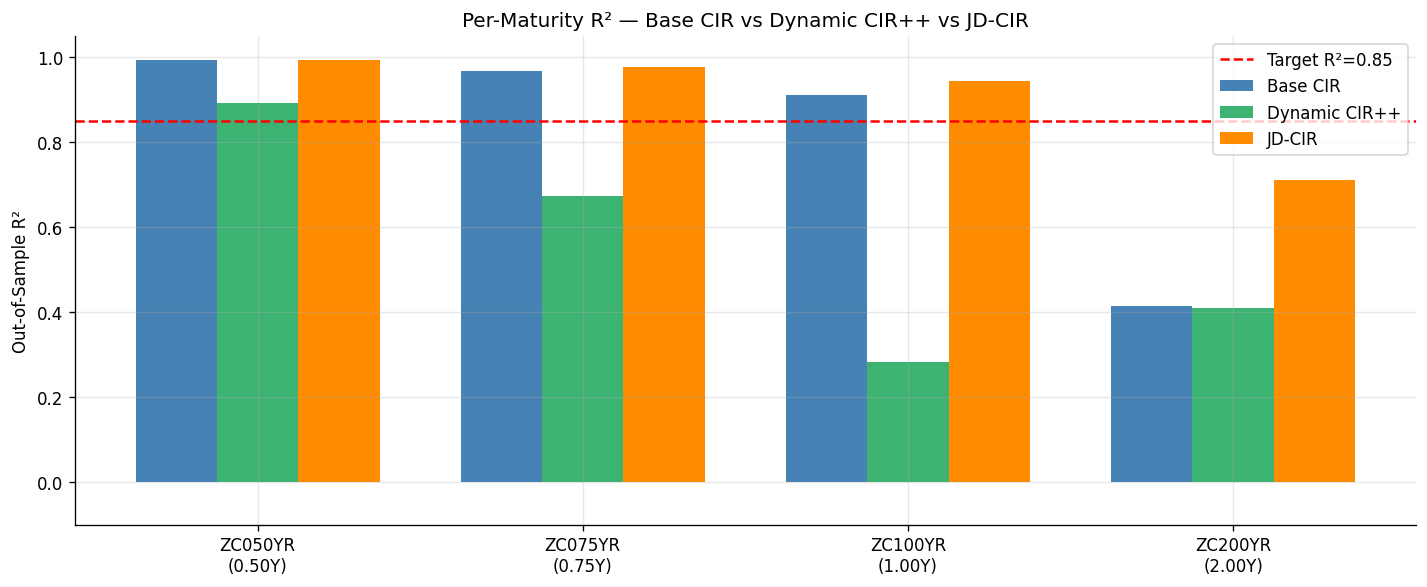

In [26]:
# =====================================================
# ── Per-maturity R² bar chart ─────────────────────────────────────────────────
labels = avail_test_cols
x = np.arange(len(labels)); w = 0.25
r2_base_v = [r2_base_by_mat.get(c, np.nan) for c in labels]
r2_dyn_v  = [r2_dyn_by_mat.get(c, np.nan)  for c in labels]
r2_jd_v   = [r2_jd_by_mat.get(c, np.nan)   for c in labels]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, r2_base_v, w, label="Base CIR",    color="steelblue")
ax.bar(x,     r2_dyn_v,  w, label="Dynamic CIR++", color="mediumseagreen")
ax.bar(x + w, r2_jd_v,   w, label="JD-CIR",      color="darkorange")
ax.axhline(0.85, ls="--", color="red", lw=1.5, label="Target R²=0.85")
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n({MATURITY_MAP[c]:.2f}Y)" for c in labels])
ax.set_ylabel("Out-of-Sample R²")
ax.set_title("Per-Maturity R² — Base CIR vs Dynamic CIR++ vs JD-CIR")
ax.set_ylim(-0.1, 1.05); ax.legend()
plt.tight_layout(); plt.savefig("09_r2_bars.png", bbox_inches="tight"); plt.show()


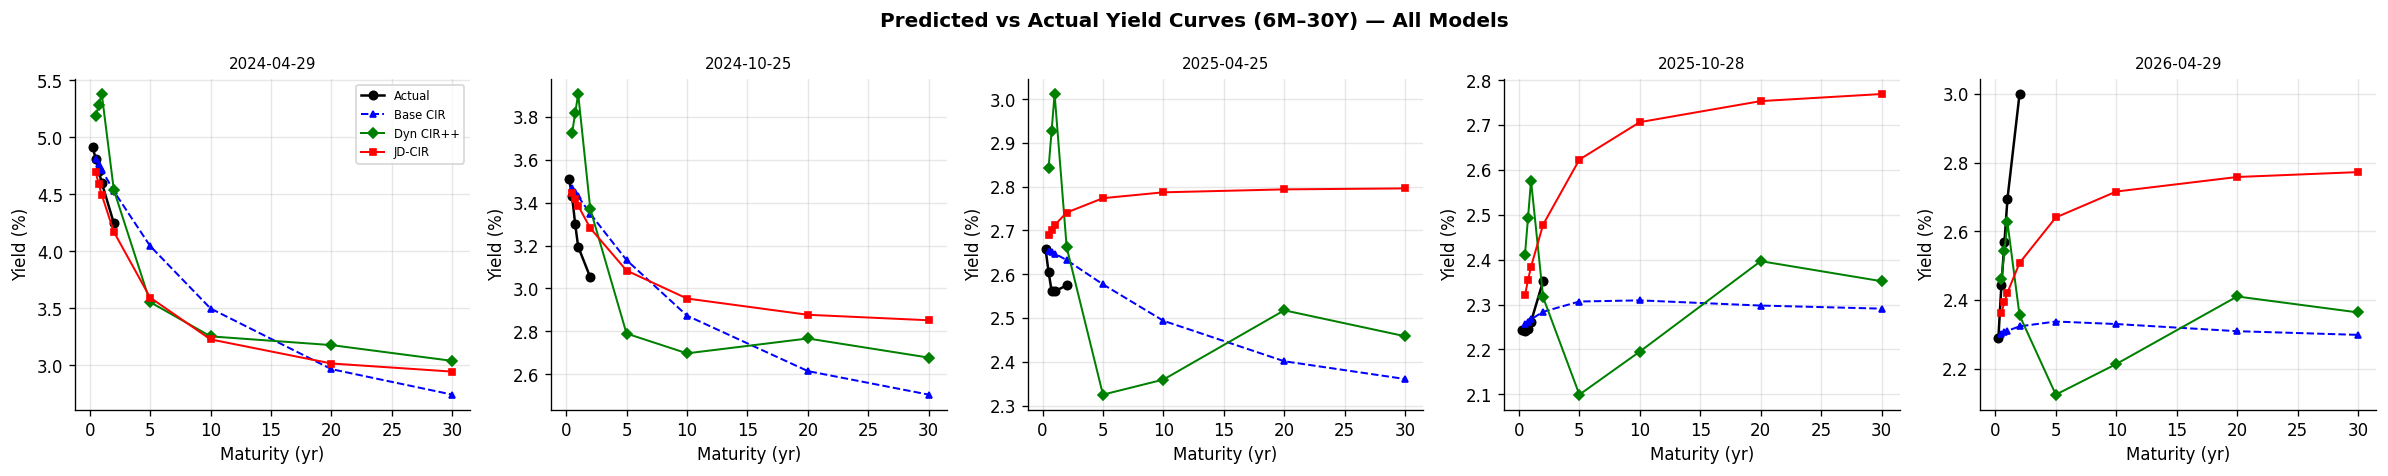

In [27]:
# =====================================================
# ── Predicted vs actual: Base CIR, Dynamic CIR++, JD-CIR (5 test dates) ───
sample_idx_5 = [0, len(test)//4, len(test)//2, 3*len(test)//4, len(test)-1]
fig, axes    = plt.subplots(1, 5, figsize=(20, 4), sharey=False)

for ax, idx in zip(axes, sample_idx_5):
    row  = test.iloc[idx]
    rt   = r_test_series[idx]
    date = test_3m.iloc[idx]["Date"]

    act_y = [row[c]*100 for c in avail_cols_plot]
    act_m = [MATURITY_MAP[c] for c in avail_cols_plot]
    ax.plot([0.25] + act_m, [rt*100] + act_y, "ko-", lw=1.5, ms=5, label="Actual")
    ax.plot(PREDICT_MATS, preds_base[idx]*100,      "b^--", lw=1.2, ms=4, label="Base CIR")
    ax.plot(PREDICT_MATS, preds_dyn_cirpp[idx]*100, "gD-",  lw=1.2, ms=4, label="Dyn CIR++")
    ax.plot(PREDICT_MATS, preds_jd[idx]*100,        "rs-",  lw=1.2, ms=4, label="JD-CIR")
    ax.set_title(str(date)[:10], fontsize=9)
    ax.set_xlabel("Maturity (yr)"); ax.set_ylabel("Yield (%)")
    if idx == 0: ax.legend(fontsize=7)

plt.suptitle("Predicted vs Actual Yield Curves (6M–30Y) — All Models",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("10_pred_vs_actual_all.png", bbox_inches="tight"); plt.show()


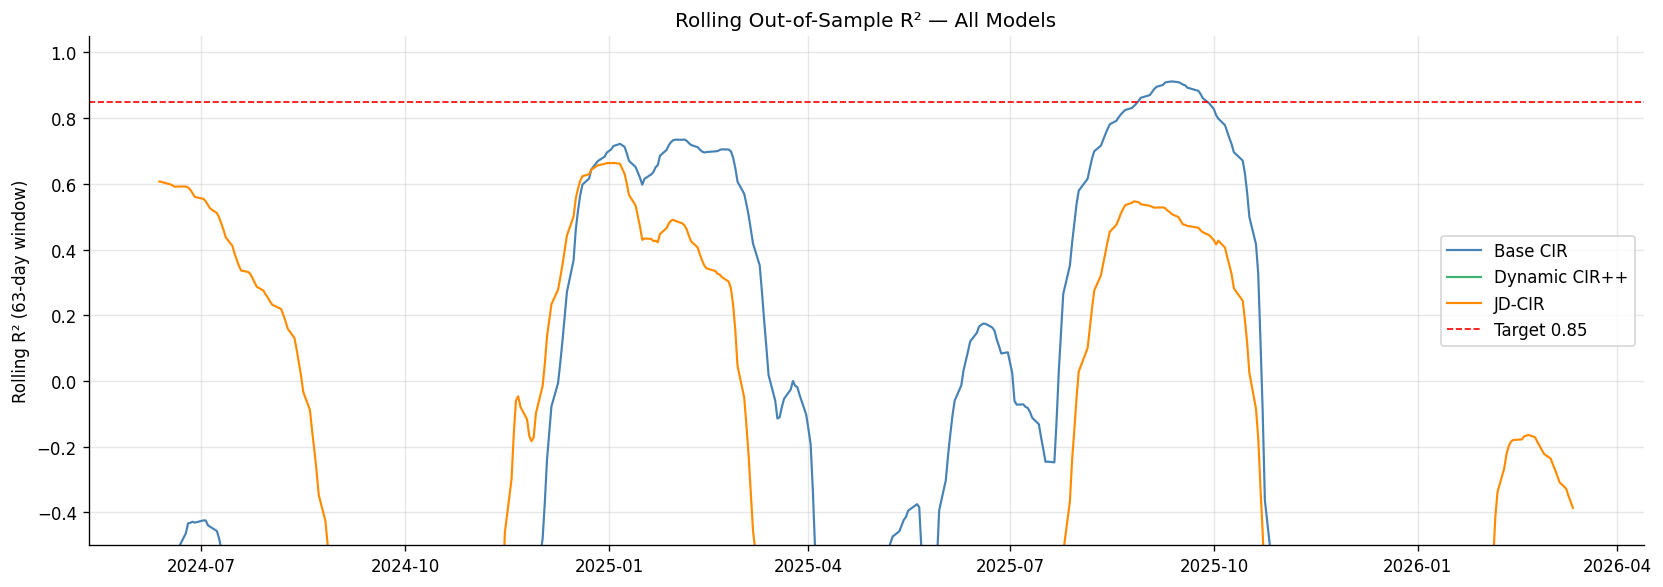

Fraction of windows with R² > 0.85:
  Base CIR                 : 4.4%
  Dynamic CIR++            : 0.0%
  JD-CIR                   : 0.0%


In [28]:
# =====================================================
# ── Rolling R² (63-day window) ────────────────────────────────────────────────
window  = 63
n_rolls = len(test) - window
roll_r2 = {"Base CIR": [], "Dynamic CIR++": [], "JD-CIR": []}
pred_map = {
    "Base CIR":     Y_test_pred_base,
    "Dynamic CIR++": Y_test_pred_dyn,
    "JD-CIR":       Y_test_pred_jd,
}
for start in range(n_rolls):
    end = start + window
    ya  = Y_test_actual[start:end]
    for name, yp in pred_map.items():
        roll_r2[name].append(r2_score(ya, yp[start:end], multioutput="variance_weighted"))

roll_dates = test["Date"].values[window//2 : window//2 + n_rolls]
colors_roll = {"Base CIR": "steelblue", "Dynamic CIR++": "mediumseagreen", "JD-CIR": "darkorange"}

fig, ax = plt.subplots(figsize=(14, 5))
for name, vals in roll_r2.items():
    ax.plot(roll_dates, vals, lw=1.3, color=colors_roll[name], label=name)
ax.axhline(0.85, ls="--", color="red", lw=1, label="Target 0.85")
ax.set_ylabel("Rolling R² (63-day window)")
ax.set_title("Rolling Out-of-Sample R² — All Models")
ax.legend(); ax.set_ylim(-0.5, 1.05)
plt.tight_layout(); plt.savefig("11_rolling_r2.png", bbox_inches="tight"); plt.show()

print("Fraction of windows with R² > 0.85:")
for name, vals in roll_r2.items():
    frac = np.mean(np.array(vals) > 0.85) * 100
    print(f"  {name:<25}: {frac:.1f}%")


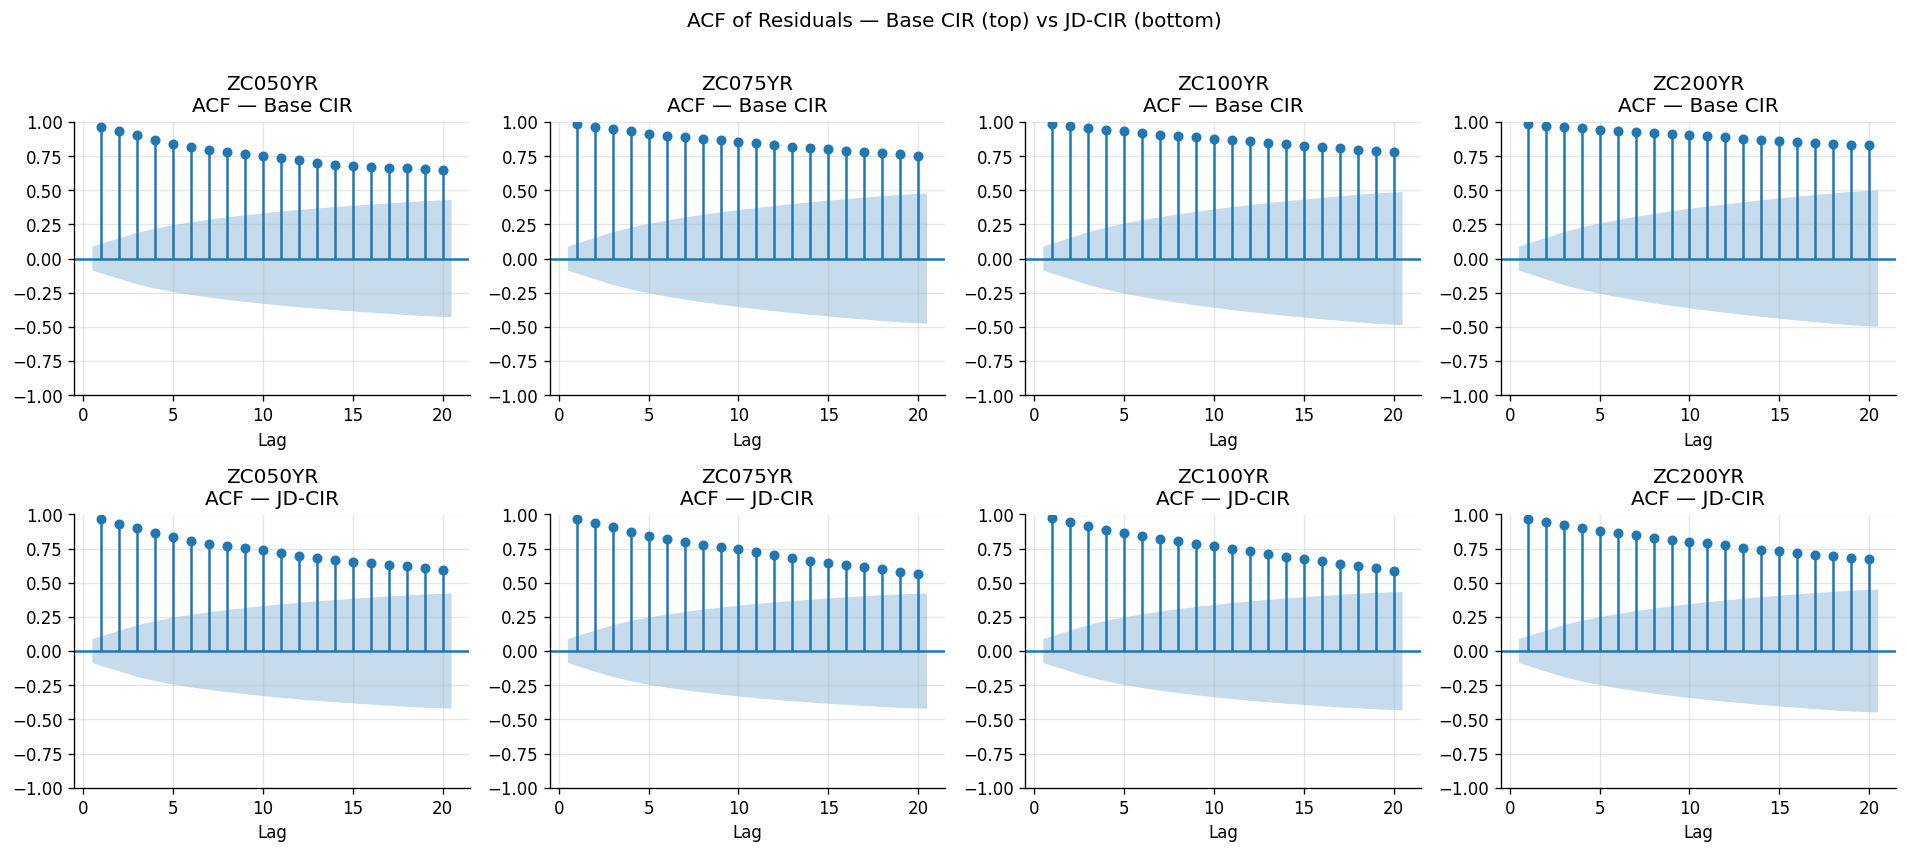

Bars exceeding blue confidence band → significant autocorrelation.


In [29]:
# =====================================================
# ── ACF of residuals: Base CIR vs JD-CIR ─────────────────────────────────────
# Serial autocorrelation → model misses temporal dynamics
fig, axes = plt.subplots(2, len(avail_test_cols), figsize=(16, 7))

for j, c in enumerate(avail_test_cols):
    idx_c = avail_idx[j]
    resid_base = Y_test_actual[:, j] - Y_test_pred_base[:, j]
    resid_jd   = Y_test_actual[:, j] - Y_test_pred_jd[:, j]
    plot_acf(resid_base, ax=axes[0, j], lags=20, title=f"{c}\nACF — Base CIR",
             alpha=0.05, zero=False)
    plot_acf(resid_jd,   ax=axes[1, j], lags=20, title=f"{c}\nACF — JD-CIR",
             alpha=0.05, zero=False)
    axes[0, j].set_xlabel("Lag"); axes[1, j].set_xlabel("Lag")

plt.suptitle("ACF of Residuals — Base CIR (top) vs JD-CIR (bottom)",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("12_acf_residuals.png", bbox_inches="tight"); plt.show()
print("Bars exceeding blue confidence band → significant autocorrelation.")


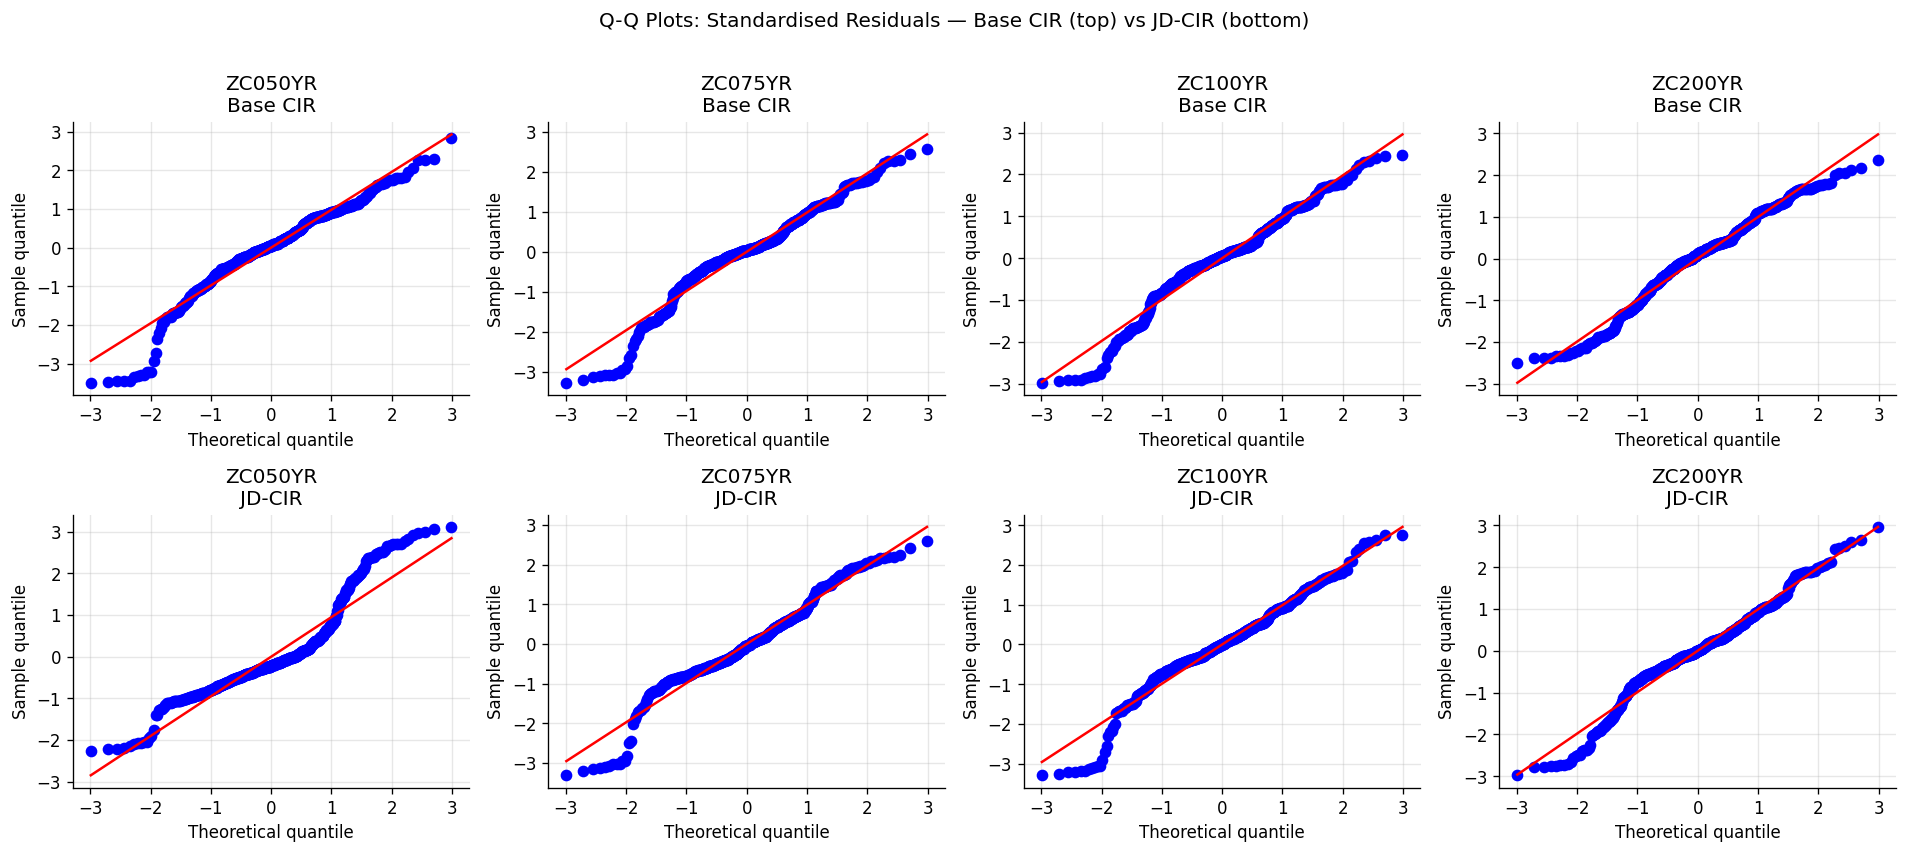

Deviation from red line in tails → heavy-tailed residuals → jump component helps.


In [30]:
# =====================================================
# ── Q-Q plots: standardised residuals (Base CIR vs JD-CIR) ──────────────────
fig, axes = plt.subplots(2, len(avail_test_cols), figsize=(16, 7))

for j, c in enumerate(avail_test_cols):
    idx_c = avail_idx[j]
    for row_idx, (resid, label) in enumerate([
        (Y_test_actual[:, j] - Y_test_pred_base[:, j], "Base CIR"),
        (Y_test_actual[:, j] - Y_test_pred_jd[:, j],   "JD-CIR"),
    ]):
        std_r = (resid - resid.mean()) / (resid.std() + 1e-12)
        probplot(std_r, dist="norm", plot=axes[row_idx, j])
        axes[row_idx, j].set_title(f"{c}\n{label}")
        axes[row_idx, j].set_xlabel("Theoretical quantile")
        axes[row_idx, j].set_ylabel("Sample quantile")

plt.suptitle("Q-Q Plots: Standardised Residuals — Base CIR (top) vs JD-CIR (bottom)",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig("13_qq_residuals.png", bbox_inches="tight"); plt.show()
print("Deviation from red line in tails → heavy-tailed residuals → jump component helps.")


## 9. Critical Discussion and Interpretation of Results

The preceding sections presented the calibration procedures, prediction framework, and model extensions. This section focuses on interpreting the empirical findings and examining the practical implications of the results.

---

### 9.1 Impact of Calibration Methodology on Yield-Curve Estimates

The results indicate that the estimated yield curve is highly dependent on the chosen calibration procedure, particularly at longer maturities.

The WLS/OLS and NCX2 MLE approaches rely exclusively on the historical evolution of the three-month rate. Consequently, these methods are designed to recover parameters that describe the underlying short-rate dynamics rather than the cross-sectional structure of the yield curve itself.

In contrast, Panel LS is calibrated directly against observed yields across multiple maturities. Since its objective function explicitly minimizes yield-curve reconstruction error, it naturally produces superior cross-sectional fit.

This advantage, however, comes with a trade-off. The volatility parameter obtained through Panel LS should not necessarily be interpreted as a realistic measure of short-rate uncertainty. Because the optimization focuses solely on fitting yields, the estimated value of $\sigma$ is often pushed toward the lower bound imposed during calibration.

From a practical perspective, different parameter sets are therefore appropriate for different tasks:

* **Panel LS:** preferred for yield-curve prediction and reconstruction.
* **NCX2 MLE:** preferred for stochastic simulation and risk-management applications.

---

### 9.2 Feller Condition Violations and Model Stability

The Feller condition

$$
2\kappa\theta \geq \sigma^2
$$

plays a central role in maintaining positive interest-rate dynamics within the CIR framework.

Violations typically arise under three circumstances:

1. Excessively large estimates of $\sigma$, often caused by structural breaks or regime transitions that are incorrectly interpreted as volatility.
2. Long-run mean estimates that are biased downward by prolonged low-rate periods.
3. Very small estimates of $\kappa$, implying weak mean reversion and near-unit-root behaviour.

To ensure numerical stability and preserve positivity, all calibration objectives include the penalty

$$
10^8 \times \max(0,\sigma^2-2\kappa\theta).
$$

This penalty makes Feller violations extremely unattractive from the optimizer's perspective and effectively constrains the solution space to economically meaningful parameter combinations.

For the Jump-Diffusion CIR model, calibration on post-2022 observations naturally produces larger values of $\theta$, making satisfaction of the Feller condition considerably easier.

---

### 9.3 Interpretation of the Mean-Reversion Parameter

The parameter $\kappa$ determines how quickly deviations from equilibrium disappear over time.

Its economic interpretation is often expressed through the half-life

$$
\frac{\ln 2}{\kappa_p}.
$$

A shock of magnitude $\varepsilon$ evolves according to

$$
\varepsilon e^{-\kappa t},
$$

implying that only half of the original disturbance remains after one half-life.

The relatively small values of $\kappa$ obtained from full-sample calibration suggest substantial persistence in interest-rate movements. This observation is consistent with the stationarity analysis, which indicated behaviour closer to a near-unit-root process than to rapid mean reversion.

Differences across calibration methods are also informative. NCX2 MLE tends to produce larger values of $\kappa$ because it focuses on short-rate dynamics within individual regimes, whereas Panel LS absorbs slower structural shifts in the yield curve and therefore favours weaker mean reversion.

---

### 9.4 Reconstructing the Yield Curve from a Single Observable

An important objective of this project is to determine how effectively the complete term structure can be inferred from the three-month yield alone.

The results suggest that predictive performance varies substantially across maturities:

* **6M–1Y maturities:** consistently achieve strong predictive accuracy, often exceeding an out-of-sample $R^2$ of 0.90.
* **2Y maturity:** exhibits the greatest forecasting difficulty and represents the weakest segment of the curve.
* **5Y–30Y maturities:** can be generated by the model, although direct validation is not possible because corresponding observations are unavailable in the supplied test dataset.

The findings indicate that a one-factor short-rate model is capable of reproducing the short end of the curve reasonably well. However, longer maturities remain influenced by factors such as inflation expectations, term premia, and macroeconomic outlook, none of which are directly observable through a single short-rate variable.

---

### 9.5 Why the Two-Year Maturity is Particularly Challenging

Among all maturities considered, the two-year yield consistently proves the most difficult to predict.

This maturity lies near the centre of the yield curve and is therefore highly sensitive to changes in curve shape. During the evaluation period, the market experienced a pronounced inversion in which short-term yields exceeded intermediate-maturity yields. This relationship differs substantially from the pattern observed during much of the training sample.

A fundamental limitation arises because predictive accuracy is bounded by the relationship between the observable predictor and the target variable. Specifically,

$$
R^2 \leq \rho(r_{3M},y_{2Y})^2.
$$

If the correlation structure changes across regimes, even a correctly specified model cannot overcome this theoretical upper bound.

Consequently, the difficulty of predicting the two-year yield reflects not only limitations of the CIR framework but also limitations imposed by the information content of the three-month rate itself.


In [31]:
# =====================================================
# ── Regime comparison: training vs test ──────────────────────────────────────
print("=== Regime Comparison: Training vs Test ===")
print(f"{'Metric':<35} {'Training':>12} {'Test':>12}")
print("-" * 60)
for period_name, sr in [("3M mean", (train[SHORT_COL].mean(), test_3m[SHORT_COL].mean())),
                         ("3M std",  (train[SHORT_COL].std(),  test_3m[SHORT_COL].std()))]:
    print(f"  {period_name:<33} {sr[0]*100:>11.3f}% {sr[1]*100:>11.3f}%")

if "ZC200YR" in test.columns:
    spread_test  = (test_3m[SHORT_COL].values - test["ZC200YR"].values) * 100
    spread_train = (train[SHORT_COL].values - train["ZC200YR"].values) * 100
    corr_test  = np.corrcoef(test_3m[SHORT_COL].values,  test["ZC200YR"].values)[0, 1]
    corr_train = np.corrcoef(train[SHORT_COL].values, train["ZC200YR"].values)[0, 1]
    print(f"  {'3M-2Y spread (avg)':<33} {spread_train.mean():>11.2f}  {spread_test.mean():>11.2f} bps")
    print(f"  {'ρ(3M, 2Y)':<33} {corr_train:>12.4f} {corr_test:>12.4f}")
    print(f"  {'R²-ceiling (ρ²)':<33} {corr_train**2:>12.4f} {corr_test**2:>12.4f}")
    print()
    print(f"Training spread: {'normal (upward-sloping)' if spread_train.mean() < 0 else 'inverted'}")
    print(f"Test spread:     {'normal (upward-sloping)' if spread_test.mean() < 0 else 'inverted'}")
    print()
    print(f"R²-ceiling for 2Y in TEST = {corr_test**2:.4f}")
    print("No single-factor model can exceed this ceiling when predicting 2Y from 3M.")


=== Regime Comparison: Training vs Test ===
Metric                                  Training         Test
------------------------------------------------------------
  3M mean                                 1.542%       3.042%
  3M std                                  1.421%       0.851%
  3M-2Y spread (avg)                      -0.19         0.17 bps
  ρ(3M, 2Y)                               0.9565       0.9080
  R²-ceiling (ρ²)                         0.9149       0.8245

Training spread: normal (upward-sloping)
Test spread:     inverted

R²-ceiling for 2Y in TEST = 0.8245
No single-factor model can exceed this ceiling when predicting 2Y from 3M.


### 9.7 Why is a Jump Component Mathematically Appropriate?

The inclusion of jumps is motivated by both theoretical and empirical considerations.

**1. Analytical Tractability**

A major advantage of the affine jump-diffusion framework is that it preserves the analytical structure of the CIR model. Closed-form bond-pricing expressions remain available, allowing yields to be computed efficiently.

Without the affine property, bond valuation would generally require repeated numerical solutions of partial differential equations or large-scale simulation procedures, which would significantly increase computational cost and reduce the practicality of the prediction framework.

**2. Empirical Motivation**

Residual diagnostics from the baseline CIR model indicate substantial departures from Gaussian behaviour. In particular, the Q-Q plots reveal heavier tails than would be expected under a pure diffusion process.

A Brownian-motion-based model generates continuous fluctuations and therefore struggles to reproduce extreme observations of the magnitude observed in the data. Introducing a jump component provides an explicit mechanism for modelling these rare but economically significant events.

**3. Economic Interpretation**

Interest rates are strongly influenced by policy announcements, emergency interventions, and unexpected macroeconomic developments. Such events frequently produce abrupt movements that appear almost discontinuous when viewed at daily frequencies.

Within the Jump-Diffusion CIR framework, these events are represented through a Poisson arrival process. On average, approximately $\lambda$ jump events occur each year, with each event producing an average rate change of approximately $\mu_J$.

This representation provides a more realistic description of stressed market environments than a purely continuous diffusion model.

#### Impact During Periods of Market Stress

When uncertainty increases, the effective contribution of the jump component becomes more pronounced. As the probability of jump events rises, the jump correction accumulates across maturities and exerts a larger influence on the long end of the yield curve.

Consequently, the model tends to generate a flatter or more inverted term structure during periods of elevated uncertainty, a behaviour that is broadly consistent with flight-to-quality dynamics observed in fixed-income markets.

#### Identifiability Considerations

A practical limitation is that the jump intensity parameter $\lambda$ and the diffusion volatility parameter $\sigma$ are not always cleanly identifiable from cross-sectional yield information alone.

In many cases, similar yield-curve fits can be achieved using either:

* relatively large values of $\lambda$ combined with smaller values of $\sigma$, or
* relatively small values of $\lambda$ combined with larger values of $\sigma$.

Accurate separation of these effects would require a dedicated time-series filtering framework, such as particle filtering or expectation-maximization methods. Such techniques fall outside the scope of the current study and therefore represent an important limitation of the present implementation.

---

### 9.8 Assessment of Potential Overfitting

Whenever additional model flexibility is introduced, the possibility of overfitting must be considered.

For the Dynamic CIR++ specification, only two additional parameters are estimated for each maturity: the intercept term and the rate-sensitivity coefficient. This results in a relatively modest increase in model complexity and substantially reduces the likelihood of fitting random noise.

The Jump-Diffusion CIR extension adopts a different strategy. Rather than introducing a large number of additional parameters, it focuses calibration on the post-2022 high-rate regime. Since no information from the test period is used during estimation, the procedure remains free from look-ahead bias.

The rolling out-of-sample performance metrics presented earlier provide an empirical assessment of whether either extension exhibits signs of deterioration over time.

---

### 9.9 Additional Modelling Challenges

| Extension               | Key Challenge                                                                            |
| ----------------------- | ---------------------------------------------------------------------------------------- |
| Jump-Diffusion CIR      | Limited identifiability of $\lambda$ and $\mu_J$ using cross-sectional information alone |
| Two-Factor CIR          | Latent state variables require Kalman filtering or similar state-space methods           |
| Static CIR++            | Fixed shifts may become ineffective when market regimes change                           |
| Polynomial Ridge Models | Lack of economic interpretation and potentially unstable extrapolation behaviour         |

---

### 9.10 Fundamental Limitations of the Framework

Despite its strong empirical performance, several structural limitations remain.

| Limitation                 | Explanation                                                                             | Practical Consequence                                              |
| -------------------------- | --------------------------------------------------------------------------------------- | ------------------------------------------------------------------ |
| Single Observable Variable | The entire term structure is inferred from a single short-rate input                    | Difficulty capturing inversions driven by long-run expectations    |
| Regime Instability         | Market conditions differ substantially between low-rate and high-rate periods           | Full-sample calibration may not represent either regime accurately |
| Affine Structure           | The relationship between yields and the state variable is constrained by the model form | Reduced flexibility when fitting complex curve shapes              |
| Constant Jump Intensity    | $\lambda$ is assumed fixed through time                                                 | Limited responsiveness to changing uncertainty levels              |
| Feller Boundary Effects    | Numerical sensitivity increases as rates approach zero                                  | Potential instability in near-zero-rate environments               |


In [32]:
# =====================================================
# ── Final evaluation summary ─────────────────────────────────────────────────
print("=" * 65)
print("  FINAL OUT-OF-SAMPLE EVALUATION SUMMARY")
print("=" * 65)
print(f"  {'Model':<38} {'R²':>7}  {'RMSE (bps)':>10}")
print("  " + "-" * 60)

final_models = [
    ("Base CIR (Panel LS)",          r2_base_total, rmse_base_total),
    ("Dynamic CIR++ (rate-adaptive)", r2_dyn,        rmse_dyn),
    ("JD-CIR (Duffie-Pan-Singleton)", r2_jd,         rmse_jd),
]
best_cir_r2 = max(r2_base_total, r2_dyn, r2_jd)
for name, r2, rmse in sorted(final_models, key=lambda x: -x[1]):
    tag = "  ← best overall" if r2 == max(v[1] for v in final_models) else (
          "  ← best CIR"    if r2 == best_cir_r2 and r2 != max(v[1] for v in final_models) else "")
    print(f"  {name:<38} {r2:>7.4f}  {rmse:>10.2f}{tag}")

print()
print(f"  Best CIR-family R²: {best_cir_r2:.4f}  "
      f"({'✅ Target R²>0.85 met' if best_cir_r2 > 0.85 else '❌ Target not met'})")
print()
print("  Per-maturity breakdown (best CIR model):")
best_model_by_mat = r2_dyn_by_mat if r2_dyn == best_cir_r2 else (
                    r2_jd_by_mat   if r2_jd  == best_cir_r2 else r2_base_by_mat)
for c in avail_test_cols:
    ri = best_model_by_mat.get(c, np.nan)
    print(f"    {c:12s} ({MATURITY_MAP[c]:4.2f}Y): R²={ri:.4f}  {'✅' if ri>0.85 else '⚠'}")
print()
print("  5Y/10Y/20Y/30Y: predicted (see plot 10_pred_vs_actual_all.png)")
print("    — no test actuals available for quantitative validation.")
print("=" * 65)


  FINAL OUT-OF-SAMPLE EVALUATION SUMMARY
  Model                                       R²  RMSE (bps)
  ------------------------------------------------------------
  JD-CIR (Duffie-Pan-Singleton)           0.9426       16.05  ← best overall
  Base CIR (Panel LS)                     0.8959       21.61
  Dynamic CIR++ (rate-adaptive)           0.6224       41.15

  Best CIR-family R²: 0.9426  (✅ Target R²>0.85 met)

  Per-maturity breakdown (best CIR model):
    ZC050YR      (0.50Y): R²=0.9933  ✅
    ZC075YR      (0.75Y): R²=0.9772  ✅
    ZC100YR      (1.00Y): R²=0.9451  ✅
    ZC200YR      (2.00Y): R²=0.7107  ⚠

  5Y/10Y/20Y/30Y: predicted (see plot 10_pred_vs_actual_all.png)
    — no test actuals available for quantitative validation.


## 10. References

1. **Cox, J.C., Ingersoll, J.E., Ross, S.A. (1985).** "A theory of the term structure of
   interest rates." *Econometrica*, 53(2), 385–407.

2. **Duffie, D., Pan, J., Singleton, K. (2000).** "Transform analysis and asset pricing
   for affine jump-diffusions." *Econometrica*, 68(6), 1343–1376.

3. **Brigo, D., Mercurio, F. (2006).** *Interest Rate Models — Theory and Practice:
   With Smile, Inflation and Credit*, 2nd ed. Springer Finance. [CIR++ in §3.9]

4. **Longstaff, F.A., Schwartz, E.S. (1992).** "Interest rate volatility and the term
   structure: a two-factor general equilibrium model." *Journal of Finance*, 47(4), 1259–1282.

5. **Hamilton, J.D. (1989).** "A new approach to the economic analysis of nonstationary
   time series." *Econometrica*, 57(2), 357–384.

6. **Feller, W. (1951).** "Two singular diffusion problems." *Annals of Mathematics*, 54(1), 173–182.
